In [1]:
import os, glob, gc, cudf
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, RobustScaler, StandardScaler
import warnings
import copy

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

# 1. CẤU HÌNH ĐƯỜNG DẪN GỐC
ROOT_PATH = '/kaggle/input/datasets/qyn041220ntt/ics-nad/Dataset'

# 2. CỘT GÂY RÒ RỈ (Xóa ngay để mô hình học hành vi, không học vẹt IP/MAC)
LEAKAGE_COLS = [
    'sAddress', 'rAddress', 'sMACs', 'rMACs', 'sIPs', 'rIPs',
    'startDate', 'endDate', 'start', 'end', 'startOffset', 'endOffset'
]

# 3. MAPPING NHÃN (Xử lý lỗi chính tả và chữ hoa/thường cho cả 2 bộ)
LABEL_MAPPING = {
    'ACKPFLOOD': 'ACKFLOOD',
    'SMURF': 'SMURF', 'Smurf': 'SMURF',
    'FRAGGLE': 'FRAGGLE', 'Fraggle': 'FRAGGLE',
    'WINNUKE': 'WINNUKE', 'WinNuke': 'WINNUKE',
    'TCP': 'FDI_WRONG_FLAGS', 'SYN': 'FDI_WRONG_FLAGS',
    'ICMPBIG': 'ICMP_BIG_PKT',
    'ICMPREDIRECT': 'ICMP_REDIRECT',
    'ICMPNOTREATH': 'ICMP_NOT_REACH',
    'ICMPNOTREACH': 'ICMP_NOT_REACH',
    'PINGOFDEATH': 'POD'
}

 Device: cuda


In [2]:
schneider_files = glob.glob(f'{ROOT_PATH}/Schneider/*.csv')
siemens_files = glob.glob(f'{ROOT_PATH}/Siemens/*.csv')

print(f" Schneider: {len(schneider_files)} files")
print(f" Siemens: {len(siemens_files)} files")

 Schneider: 27 files
 Siemens: 16 files


VERSION 2

In [3]:
import cudf
import glob
import os
import pandas as pd

# 1. Cấu hình Mapping để chuẩn hóa nhãn (Typos & Consistency)
LABEL_MAPPING = {
    'ACKPFLOOD': 'ACKFLOOD',
    'SMURF': 'SMURF', 'Smurf': 'SMURF',
    'FRAGGLE': 'FRAGGLE', 'Fraggle': 'FRAGGLE',
    'WINNUKE': 'WINNUKE', 'WinNuke': 'WINNUKE',
    'TCP': 'FDI_WRONG_FLAGS', 'SYN': 'FDI_WRONG_FLAGS',
    'ICMPBIG': 'ICMP_BIG_PKT',
    'ICMPREDIRECT': 'ICMP_REDIRECT',
    'ICMPNOTREATH': 'ICMP_NOT_REACH',
    'ICMPNOTREACH': 'ICMP_NOT_REACH',
    'PINGOFDEATH': 'POD'
}

def get_slide_stats(vendor_name, skip_files=[]):
    path = f'{ROOT_PATH}/{vendor_name}'
    files = [f for f in glob.glob(f'{path}/*.csv') if os.path.basename(f) not in skip_files]
    
    all_labels = []
    
    for f in files:
        try:
            # 1. Kiểm tra header nhanh bằng GPU
            header = cudf.read_csv(f, nrows=0).columns.tolist()
            
            # 2. Xác định cột nhãn hiện có trong file
            possible_cols = ['Label', 'label', 'class', 'state']
            valid_cols = [c for c in header if c in possible_cols]
            
            if not valid_cols:
                continue
                
            # 3. Đọc cột nhãn và chuẩn hóa sơ bộ (String + Upper + Strip)
            df_tmp = cudf.read_csv(f, usecols=valid_cols)
            df_tmp.columns = ['label'] * len(df_tmp.columns)
            
            # Chuyển sang Pandas để xử lý chuỗi và mapping linh hoạt hơn
            df_cpu = df_tmp['label'].to_pandas().astype(str).str.upper().str.strip()
            
            # 4. Áp dụng LABEL_MAPPING
            df_cpu = df_cpu.replace(LABEL_MAPPING)
            
            all_labels.append(df_cpu)
            
        except Exception as e:
            print(f"❌ Lỗi khi đọc file {os.path.basename(f)}: {e}")
            continue

    if not all_labels:
        print(f"Empty data for {vendor_name}")
        return

    # Gộp tất cả các Series nhãn lại
    full_labels = pd.concat(all_labels, ignore_index=True)
    
    # 5. Tính toán thống kê
    stats = full_labels.value_counts()
    total = stats.sum()
    
    print(f"\n{'='*60}\n THỐNG KÊ ĐÃ CHUẨN HÓA: {vendor_name.upper()} (TỔNG: {total:,} MẪU)\n{'='*60}")
    print(f"{'Tên Nhãn':<22} | {'Số lượng':<12} | {'Tỷ lệ (%)'}")
    print("-" * 60)
    for label, count in stats.items():
        print(f"{str(label):<22} | {count:<12,} | {(count/total)*100:.4f}%")

# Thực hiện thống kê cho các thiết bị mạng trong hệ thống ICS
get_slide_stats('Schneider')
get_slide_stats('Siemens', skip_files=['Siemens_tcpall0_0709.csv', 'Siemens_tcpsynfin0_0709.csv', 'Siemens_teardrop_0709.csv', 'Siemens_tcpfin1_0709.csv'])


 THỐNG KÊ ĐÃ CHUẨN HÓA: SCHNEIDER (TỔNG: 20,015,864 MẪU)
Tên Nhãn               | Số lượng     | Tỷ lệ (%)
------------------------------------------------------------
BENIGN                 | 5,043,069    | 25.1954%
ACKFLOOD               | 4,981,420    | 24.8874%
SYNFLOOD               | 4,979,260    | 24.8766%
ICMPFLOOD              | 4,975,772    | 24.8591%
FDI_WRONG_FLAGS        | 12,003       | 0.0600%
SMURF                  | 5,240        | 0.0262%
WINNUKE                | 4,201        | 0.0210%
FRAGGLE                | 2,761        | 0.0138%
ICMP_BIG_PKT           | 2,436        | 0.0122%
POD                    | 2,397        | 0.0120%
ROUTEIP                | 2,376        | 0.0119%
TEARDROP               | 2,370        | 0.0118%
LAND                   | 2,322        | 0.0116%
ARP                    | 184          | 0.0009%
ICMP_REDIRECT          | 24           | 0.0001%
ICMP_NOT_REACH         | 17           | 0.0001%
PORTSCAN               | 12           | 0.0001%

 THỐNG KÊ 

**1. Zero-day Tàng hình (Stealthy Zero-day):** Dùng ARP, PORTSCAN, ICMP_REDIRECT làm Open-set. Đặc điểm của chúng là số lượng mẫu cực kỳ ít (chỉ vài chục đến vài trăm gói tin) và thực hiện việc thăm dò, thao túng lén lút (surreptitiously)
. MET phát hiện chúng bằng độ Bất định (Vacuity).

**2. Zero-day Bạo lực (Flooding Zero-day)**: Dùng ACKFLOOD làm Open-set. Đặc điểm của nó là số lượng mẫu cực kỳ lớn do bản chất là đòn ngập lụt mạng. Kẻ tấn công dùng nó như một đòn Zero-day mới tinh, mang vỏ bọc rất giống đòn SYNFLOOD (đã biết). Mặc dù có hàng triệu gói tin ập vào, MET chỉ cần phân tích một vài gói tin (Few-shot) là đã soi ra được sự bất thường nhờ chỉ số Tỷ lệ Bằng chứng trên Phương sai (EVR) và chặn đứng cả chiến dịch


In [4]:
# =====================================================================
# Load & Cleaning data 
# =====================================================================
def load_data(csv_path_list, leakage_cols, label_mapping, max_samples_per_class=20000):
    """
    Hàm đọc toàn bộ file CSV, làm sạch dữ liệu, xóa cột rò rỉ và chuẩn hóa Nhãn.
    Trả về một DataFrame duy nhất chứa toàn bộ dữ liệu.
    """
    df_list = []
    
    for file_path in tqdm(csv_path_list, desc="Đang đọc và làm sạch dữ liệu"):
        df = pd.read_csv(file_path)
        possible_label_names = ['state', 'Label', 'label', 'class']
        
        # 1. Xóa các cột chứa Meta data gây rò rỉ dữ liệu
        cols_to_drop = [c for c in leakage_cols if c in df.columns]
        df.drop(columns=cols_to_drop, inplace=True)
        
        # 2. Xử lý giá trị lỗi (Infinity và NaN)
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.fillna(0, inplace=True)

        # 3. Chuẩn hóa tên cột Nhãn
        found_col = None
        for col in possible_label_names:
            if col in df.columns:
                df.rename(columns={col: 'Label'}, inplace=True)
                found_col = 'Label'
                break
            
        if found_col:
            # Chuẩn hóa nội dung nhãn
            df['Label'] = df['Label'].astype(str).str.strip().str.upper()
            df['Label'] = df['Label'].replace(label_mapping)
           
            # 4. DOWNSAMPLING: Lấy mẫu phân tầng để cân bằng và tiết kiệm RAM
            df = df.groupby('Label', group_keys=False).apply(
                lambda x: x.sample(n=min(len(x), max_samples_per_class), random_state=42)
            )
                
            df_list.append(df)
            
        del df
        gc.collect()

    print("\n[+] Đang gộp các phần dữ liệu thành DataFrame tổng...")
    final_df = pd.concat(df_list, ignore_index=True)
    return final_df

In [5]:
import glob
import os

TARGET_VENDOR = 'Schneider' 

# Danh sách file Siemens cần loại bỏ
SKIP_SIEMENS_FILES = [
    'Siemens_tcpall0_0709.csv', 'Siemens_tcpsynfin0_0709.csv', 
    'Siemens_teardrop_0709.csv', 'Siemens_tcpfin1_0709.csv'
]

# 1. Thu thập tất cả file .csv
all_csv_files = glob.glob(f"{ROOT_PATH}/{TARGET_VENDOR}/*.csv", recursive=True)

# 2. Lọc file theo TARGET_VENDOR
if TARGET_VENDOR == 'Siemens':
    # Lấy tất cả, nhưng vẫn loại bỏ các file Siemens lỗi
    csv_files = [f for f in all_csv_files if os.path.basename(f) not in SKIP_SIEMENS_FILES]
else:
    csv_files = [f for f in all_csv_files]

print(f"\n Tìm thấy {len(csv_files)} file CSV.")

# Thực thi Load data
if len(csv_files) > 0:
    df_all = load_data(csv_files, LEAKAGE_COLS, LABEL_MAPPING, max_samples_per_class=20000)
    print(f"\n[OK] Load thành công bộ dữ liệu {TARGET_VENDOR}!")
else:
    print(f" Không tìm thấy file nào cho vendor: {TARGET_VENDOR}")

if 'Label' in df_all.columns:
    print("\n" + "="*60)
    print(f" Chi tiết phân phối lớp: {TARGET_VENDOR.upper()}")
    print("="*60)
    
    # 1. Tính toán số lượng và tỷ lệ
    class_counts = df_all['Label'].value_counts().reset_index()
    class_counts.columns = ['Lớp', 'Số lượng']
    class_counts['Tỷ lệ (%)'] = (class_counts['Số lượng'] / len(df_all) * 100).round(2)
    
    # 2. In bảng thống kê
    print(class_counts.to_string(index=False))
    
    print("-" * 60)
    print(f" Tổng: {len(df_all):,} mẫu | {df_all['Label'].nunique()} lớp")
    print("="*60)


 Tìm thấy 27 file CSV.


Đang đọc và làm sạch dữ liệu: 100%|██████████| 27/27 [03:14<00:00,  7.21s/it]



[+] Đang gộp các phần dữ liệu thành DataFrame tổng...

[OK] Load thành công bộ dữ liệu Schneider!

 Chi tiết phân phối lớp: SCHNEIDER
            Lớp  Số lượng  Tỷ lệ (%)
         BENIGN     84287      45.45
      ICMPFLOOD     22416      12.09
       ACKFLOOD     22395      12.08
       SYNFLOOD     20000      10.79
FDI_WRONG_FLAGS     12003       6.47
          SMURF      5240       2.83
        WINNUKE      4201       2.27
        FRAGGLE      2761       1.49
   ICMP_BIG_PKT      2436       1.31
            POD      2397       1.29
        ROUTEIP      2376       1.28
       TEARDROP      2370       1.28
           LAND      2322       1.25
            ARP       184       0.10
  ICMP_REDIRECT        24       0.01
 ICMP_NOT_REACH        17       0.01
       PORTSCAN        12       0.01
------------------------------------------------------------
 Tổng: 185,441 mẫu | 17 lớp


In [6]:
#====================================================================
# Tách tập dữ liệu ( SỬ DỤNG CÂY PHÂN CẤP)
#====================================================================

# Cấu trúc cây phân cấp ngữ nghĩa
ics_taxonomy = {
    # Nhóm 1: Lưu lượng bình thường
    'Normal': ['BENIGN'],
    # Nhóm 2: DoS/DDoS  dựa trên lưu lượng - Dùng Hping2
    'DoS_Flood': ['SYNFLOOD','ACKFLOOD','ICMPFLOOD', 'SMURF','FRAGGLE'],
    # Nhóm 3: DoS/DDoS dựa trên lỗi giao thức (Malformed) - Tác động vào logic xử lý
    'DoS_Protocol': ['TEARDROP', 'LAND', 'WINNUKE', 'POD'],
    # Nhóm 4: Tiêm dữ liệu giả & thao túng 
    'FDI_Injection' : ['FDI_WRONG_FLAGS', 'ICMP_BIG_PKT'],
    # Nhóm 5: Thăm dò & Man in the Middle
    'Recon_MitM': ['ROUTEIP', 'ARP']
}

def get_data_by_taxonomy (df, taxonomy_dict):
    """
    Nhãn có trong taxonomy -> Trainable
    """
    
    trainable_classes = [cls for group in taxonomy_dict.values() for cls in group]
    df_trainable = df[df['Label'].isin(trainable_classes)].copy()

    print("\n" + "="*60)
    print(" KẾT QUẢ CHIA TẬP THEO CÂY PHÂN CẤP (TAXONOMY)")
    print("="*60)

    label_to_category = {}
    for category, labels in ics_taxonomy.items():
        for lbl in labels:
            label_to_category[lbl] = category
    
    # Thống kê tập TRAINABLE
    stats = df_trainable['Label'].value_counts().reset_index()
    stats.columns = ['Tên Nhãn', 'Số lượng']
    stats['Nhóm Ngữ nghĩa'] = stats['Tên Nhãn'].map(label_to_category)
    
    # Sắp xếp lại thứ tự cột
    stats = stats[['Tên Nhãn', 'Nhóm Ngữ nghĩa', 'Số lượng']]
    
    # Hiển thị bảng
    print("\n" + "="*85)
    print(" BẢNG THỐNG KÊ CHI TIẾT CẤU TRÚC DỮ LIỆU CHO MÔ HÌNH MET")
    print("="*85)
    print(stats.sort_values(by=['Số lượng'], ascending=False).to_string(index=False))
    
    return df_trainable
    

In [7]:
df_trainable_tax_raw = get_data_by_taxonomy(df_all, ics_taxonomy)


 KẾT QUẢ CHIA TẬP THEO CÂY PHÂN CẤP (TAXONOMY)

 BẢNG THỐNG KÊ CHI TIẾT CẤU TRÚC DỮ LIỆU CHO MÔ HÌNH MET
       Tên Nhãn Nhóm Ngữ nghĩa  Số lượng
         BENIGN         Normal     84287
      ICMPFLOOD      DoS_Flood     22416
       ACKFLOOD      DoS_Flood     22395
       SYNFLOOD      DoS_Flood     20000
FDI_WRONG_FLAGS  FDI_Injection     12003
          SMURF      DoS_Flood      5240
        WINNUKE   DoS_Protocol      4201
        FRAGGLE      DoS_Flood      2761
   ICMP_BIG_PKT  FDI_Injection      2436
            POD   DoS_Protocol      2397
        ROUTEIP     Recon_MitM      2376
       TEARDROP   DoS_Protocol      2370
           LAND   DoS_Protocol      2322
            ARP     Recon_MitM       184


In [8]:
from scipy.spatial.distance import cdist
#=========================================================================
# Tách tập dữ liệu (SỬ DỤNG FEATURE SPACE ANALYSIS - Ma trận khoảng cách )
#=========================================================================
def get_data_by_build_distance_matrix(df):
    """
    Sử dụng KHOẢNG CÁCH MAHALANOBIS để phân tích toàn bộ không gian đặc trưng.
    Kết hợp giữa Khoảng cách Đặc trưng (Feature Space) và Số lượng mẫu (Sample Count).
    """
    print("\n Đang phân tích Không gian đặc trưng bằng MAHALANOBIS...")

    # DANH SÁCH LỚP CẦN LOẠI BỎ (Do quá ít mẫu gây lỗi rò rỉ dữ liệu)
    excluded_classes = ['ICMP_REDIRECT', 'ICMP_NOT_REACH', 'PORTSCAN']
    
    # Lọc bỏ trước khi phân tích
    df_filtered = df[~df['Label'].isin(excluded_classes)].copy()

    # Tạo bản sao tạm thời và MÃ HÓA TẠM để thuật toán toán học chạy được
    temp_df = df_filtered.copy()
    
    # Lấy danh sách các cột đặc trưng số học
    feature_cols = [c for c in df_filtered.columns if c != 'Label']

    cat_cols = temp_df[feature_cols].select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        temp_df[col] = pd.factorize(temp_df[col])[0]

    tmp_scaler = StandardScaler()
    temp_df[feature_cols] = tmp_scaler.fit_transform(temp_df[feature_cols])

    label_counts = temp_df['Label'].value_counts()
    
     # 2. Tính Centroid và Mahalanobis trên bản sao tạm
    centroids = temp_df.groupby('Label')[feature_cols].mean()
    class_names = centroids.index.tolist()
    
    cov_matrix = np.cov(temp_df[feature_cols].values, rowvar=False)
    cov_matrix += np.eye(cov_matrix.shape[0]) * 1e-6
    inv_cov_matrix = np.linalg.pinv(cov_matrix)
    
    dist_array = cdist(centroids.values, centroids.values, metric='mahalanobis', VI=inv_cov_matrix)
    dist_df = pd.DataFrame(dist_array, index=class_names, columns=class_names)
    np.fill_diagonal(dist_df.values, np.inf)

    # Thống kê tập TRAINABLE
    report = df_filtered['Label'].value_counts().reset_index()
    report.columns = ['Tên Nhãn', 'Số lượng']
    report['Tỷ lệ (%)'] = (report['Số lượng'] / report['Số lượng'].sum() * 100).round(4)
    
    print("\n" + "="*95)
    print(" BẢNG THỐNG KÊ CHI TIẾT CẤU TRÚC DỮ LIỆU CHO MÔ HÌNH MET (MAHALANOBIS SPLIT)")
    print("="*95)
    print(report.sort_values(by=['Số lượng'], ascending=False).to_string(index=False))
    print("="*95)

    closest_pair = dist_df.unstack().idxmin()
    print(f"[*] Cặp tấn công có đặc trưng mạng gần nhau nhất: {closest_pair}")
    print(f"[*] Khoảng cách Mahalanobis: {dist_df.loc[closest_pair]:.4f}")
    print("="*85)

    return df_filtered

In [9]:
df_trainable_dist_raw = get_data_by_build_distance_matrix(df_all)


 Đang phân tích Không gian đặc trưng bằng MAHALANOBIS...

 BẢNG THỐNG KÊ CHI TIẾT CẤU TRÚC DỮ LIỆU CHO MÔ HÌNH MET (MAHALANOBIS SPLIT)
       Tên Nhãn  Số lượng  Tỷ lệ (%)
         BENIGN     84287    45.4652
      ICMPFLOOD     22416    12.0914
       ACKFLOOD     22395    12.0801
       SYNFLOOD     20000    10.7882
FDI_WRONG_FLAGS     12003     6.4745
          SMURF      5240     2.8265
        WINNUKE      4201     2.2661
        FRAGGLE      2761     1.4893
   ICMP_BIG_PKT      2436     1.3140
            POD      2397     1.2930
        ROUTEIP      2376     1.2816
       TEARDROP      2370     1.2784
           LAND      2322     1.2525
            ARP       184     0.0993
[*] Cặp tấn công có đặc trưng mạng gần nhau nhất: ('FRAGGLE', 'SMURF')
[*] Khoảng cách Mahalanobis: 1.4982


**Chia tập thành Train, Eval, Test**

In [10]:
from sklearn.model_selection import train_test_split
import pandas as pd

def prepare_met_splits(df_clean):
    """
    Hàm thực hiện cắt tập dữ liệu thành Train/Eval/Test (Tỷ lệ 70-10-20).
    """
    # 1. Tách 70% cho Train, 30% cho (Eval + Test Closed)
    df_train, df_temp = train_test_split(
        df_clean, 
        test_size=0.30, 
        random_state=42, 
        stratify=df_clean['Label'] # Đảm bảo cân bằng lớp
    )

    # 2. Tách 30% temp thành: 10% Eval và 20% Test Closed
    # Để Eval chiếm 10% tổng số (bằng 1/3 của 30%), ta set test_size = 2/3 (cho Test Closed)
    df_eval, df_test = train_test_split(
        df_temp, 
        test_size=2/3, 
        random_state=42, 
        stratify=df_temp['Label']
    )

    # In báo cáo
    print(f"[+] Tập TRAIN  : {len(df_train):,} mẫu (~70%)")
    print(f"[+] Tập EVAL (Validation Closed) : {len(df_eval):,} mẫu (~10%)")
    print(f"[+] Tập TEST (Closed-set)    : {len(df_test):,} mẫu (~20%)")
    print(f"\n")
    
    feature_cols = [c for c in df_train.columns if c != 'Label']
    return df_train, df_eval, df_test, feature_cols

In [11]:
# Nhánh sử dụng CÂY PHÂN CẤP
(df_train_tax_raw, df_eval_tax_raw, df_test_tax_raw, feature_cols_tax) = prepare_met_splits( df_trainable_tax_raw)

# Nhánh sử dụng MA TRẬN KHOẢNG CÁCH
(df_train_dist_raw, df_eval_dist_raw, df_test_dist_raw, feature_cols_dist) = prepare_met_splits( df_trainable_dist_raw)

[+] Tập TRAIN  : 129,771 mẫu (~70%)
[+] Tập EVAL (Validation Closed) : 18,539 mẫu (~10%)
[+] Tập TEST (Closed-set)    : 37,078 mẫu (~20%)


[+] Tập TRAIN  : 129,771 mẫu (~70%)
[+] Tập EVAL (Validation Closed) : 18,539 mẫu (~10%)
[+] Tập TEST (Closed-set)    : 37,078 mẫu (~20%)




**Chọn lọc đặc trưng**

In [12]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

def finalize_features_and_scaling(df_train_raw, df_eval_raw, df_test_raw, feature_cols, top_k=30):
    """
    Hàm tổng hợp: 
    1. Label Encoding nhãn và các cột chuỗi.
    2. Chọn lọc Top K đặc trưng bằng Random Forest.
    3. Chuẩn hóa RobustScaler tuân thủ Zero-Leakage.
    """
    print("\n[+] Bắt đầu quy trình xử lý dữ liệu tập trung ...")
    
    # 1. Khởi tạo bản sao
    df_train = df_train_raw.copy()
    df_eval = df_eval_raw.copy()
    df_test = df_test_raw.copy()
    
    # Tách danh sách cột đặc trưng ban đầu
    initial_features = [c for c in df_train.columns if c != 'Label']

    # --- BƯỚC 1: MÃ HÓA (LABEL ENCODING) ---
    le_label = LabelEncoder()
    df_train['Label'] = le_label.fit_transform(df_train['Label'])
    df_eval['Label'] = le_label.transform(df_eval['Label'])
    df_test['Label'] = le_label.transform(df_test['Label'])
    
    cat_cols = df_train[initial_features].select_dtypes(include=['object', 'category']).columns.tolist()
    encoders = {}
    
    if cat_cols:
        for col in cat_cols:
            le = LabelEncoder()
            # Fit chỉ trên Train
            df_train[col] = le.fit_transform(df_train[col].astype(str))
            
            # Map giá trị lạ (nếu có ở tập khác) về 0 để tránh lỗi
            le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
            df_eval[col] = df_eval[col].astype(str).apply(lambda x: le_dict.get(x, 0))
            df_test[col] = df_test[col].astype(str).apply(lambda x: le_dict.get(x, 0))
            encoders[col] = le
        print(f"-> Đã mã hóa các cột chuỗi: {cat_cols}")

    # --- BƯỚC 2: CHỌN ĐẶC TRƯNG (FEATURE SELECTION) ---
    print(f"-> Đang trích xuất Top {top_k} đặc trưng bằng Random Forest...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(df_train[initial_features], df_train['Label'])
    
    feat_imp = pd.Series(rf.feature_importances_, index=initial_features).sort_values(ascending=False)
    top_features = feat_imp.head(top_k).index.tolist()

    # Trực quan hóa
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.head(top_k).values, y=feat_imp.head(top_k).index, palette='viridis')
    plt.title(f'Top {top_k} Feature Importances')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    # --- BƯỚC 3: CHUẨN HÓA (ROBUST SCALING) ---
    # Sử dụng RobustScaler vì dữ liệu ICS thường có các giá trị cực đoan (Outliers) 
    scaler = RobustScaler()
    
    # Fit & Transform trên Train
    df_train[top_features] = scaler.fit_transform(df_train[top_features])
    df_train[top_features] = np.clip(df_train[top_features], -10.0, 10.0)
    
    # Chỉ Transform trên Eval và Test
    df_eval[top_features] = scaler.transform(df_eval[top_features])
    df_eval[top_features] = np.clip(df_eval[top_features], -10.0, 10.0)
    df_test[top_features] = scaler.transform(df_test[top_features])
    df_test[top_features] = np.clip(df_test[top_features], -10.0, 10.0)

    # Lọc lại DataFrame chỉ giữ các cột Top Features và Label
    df_train = df_train[top_features + ['Label']]
    df_eval = df_eval[top_features + ['Label']]
    df_test = df_test[top_features + ['Label']]

    print(f"[OK] Đã hoàn tất! Kích thước tập Train mới: {df_train.shape}")
    return df_train, df_eval, df_test, top_features, le_label, encoders, scaler

 CHỌN LỌC ĐẶC TRƯNG CHO NHÁNH CÂY PHÂN CẤP

[+] Bắt đầu quy trình xử lý dữ liệu tập trung ...
-> Đã mã hóa các cột chuỗi: ['protocol']
-> Đang trích xuất Top 48 đặc trưng bằng Random Forest...


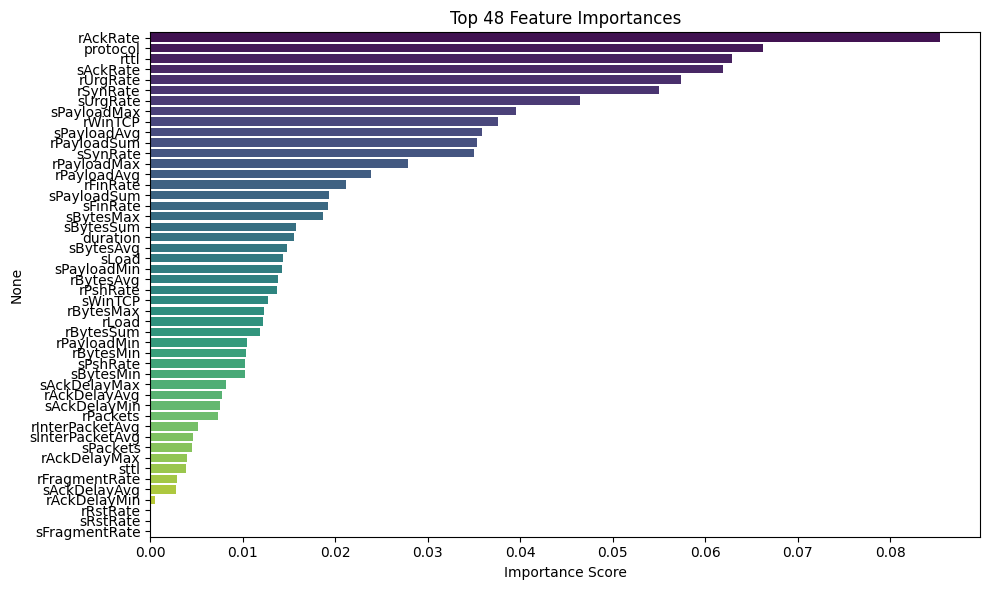

[OK] Đã hoàn tất! Kích thước tập Train mới: (129771, 49)
 CHỌN LỌC ĐẶC TRƯNG CHO NHÁNH MA TRẬN KHOẢNG CÁCH MAHALANOBIS

[+] Bắt đầu quy trình xử lý dữ liệu tập trung ...
-> Đã mã hóa các cột chuỗi: ['protocol']
-> Đang trích xuất Top 48 đặc trưng bằng Random Forest...


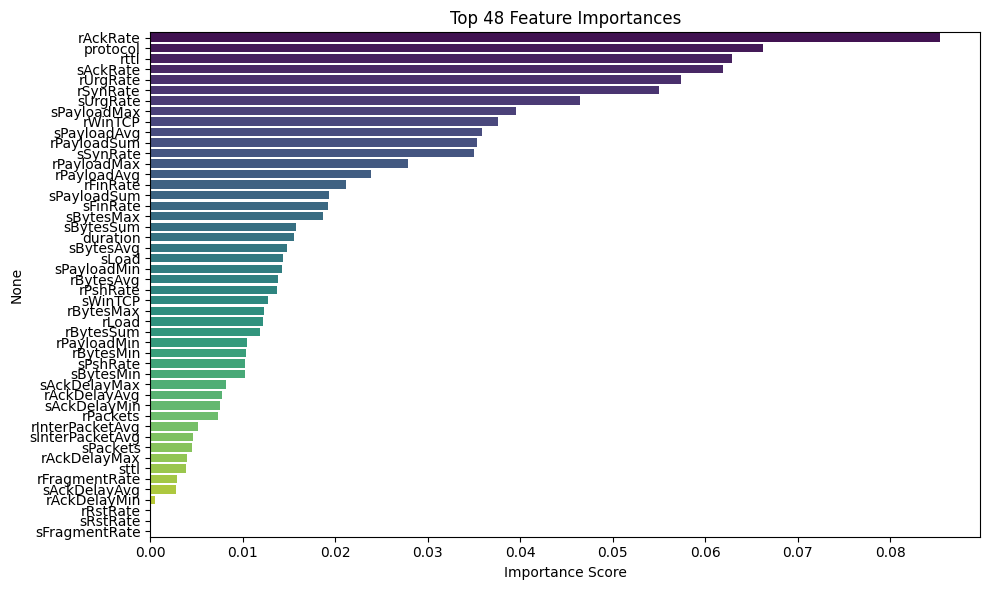

[OK] Đã hoàn tất! Kích thước tập Train mới: (129771, 49)


In [13]:
# nhánh sử dụng CÂY PHÂN CẤP
print(" CHỌN LỌC ĐẶC TRƯNG CHO NHÁNH CÂY PHÂN CẤP")
df_train_tax_clean, df_eval_tax_clean, df_test_tax_clean, top_features_tax, le_label_tax, encoders_tax, scaler_tax = finalize_features_and_scaling(
    df_train_tax_raw, 
    df_eval_tax_raw, 
    df_test_tax_raw, 
    feature_cols_tax,
    top_k=48 
)

# nhánh sử dụng MA TRẬN KHOẢNG CÁCH
print(" CHỌN LỌC ĐẶC TRƯNG CHO NHÁNH MA TRẬN KHOẢNG CÁCH MAHALANOBIS")
df_train_dist_clean, df_eval_dist_clean, df_test_dist_clean, top_features_dist, le_label_dist, encoders_dist, scaler_dist = finalize_features_and_scaling(
    df_train_dist_raw, 
    df_eval_dist_raw, 
    df_test_dist_raw, 
    feature_cols_dist,
    top_k=48 
)

In [14]:
def compute_met_distance_matrix(df_train, feature_cols):
    """
    Tính toán ma trận khoảng cách Tối hậu chỉ trên tập Train đã được chuẩn hóa.
    Ma trận này là 'Bản đồ Radar' để MET bốc lớp Opponent.
    """
    print("\n Đang xây dựng Ma trận Khoảng cách cho mạng MET...")
    
    # Tính Centroid cho các lớp Trainable
    trainable_centroids = df_train.groupby('Label')[feature_cols].mean()
    
    # Tính Hiệp phương sai và Giả nghịch đảo
    train_cov_matrix = np.cov(df_train[feature_cols].values, rowvar=False)
    train_inv_cov_matrix = np.linalg.pinv(train_cov_matrix)
    
    # Tính khoảng cách
    train_dist_array = cdist(trainable_centroids.values, trainable_centroids.values, metric='mahalanobis', VI=train_inv_cov_matrix)
    train_dist_matrix = pd.DataFrame(train_dist_array, index=trainable_centroids.index, columns=trainable_centroids.index)
    
    # Lấp đường chéo bằng vô cực để không bốc trúng chính nó làm Opponent
    np.fill_diagonal(train_dist_matrix.values, np.inf)
    
    print("[OK] Đã tạo xong Bản đồ Radar cho MET!")
    return train_dist_matrix

In [15]:
# Tính ma trận khoảng cách 
final_train_dist_matrix = compute_met_distance_matrix(df_train_dist_clean, top_features_dist)


 Đang xây dựng Ma trận Khoảng cách cho mạng MET...
[OK] Đã tạo xong Bản đồ Radar cho MET!


# BỘ TRÍCH XUẤT ĐẶC TRƯNG _ FEATURES TOKENIZATION TRANSFORMER

In [16]:
class TabularFeatureTokenizer(nn.Module):
    """Biến đổi từng đặc trưng số học thành một vector nhúng (Embedding)"""
    def __init__(self, num_features=20, embedding_dim=256):
        super(TabularFeatureTokenizer, self).__init__()
        self.num_features = num_features
        self.embedding_dim = embedding_dim
        
        # Individual weights and biases per feature
        self.weight = nn.Parameter(torch.Tensor(num_features, embedding_dim))
        self.bias = nn.Parameter(torch.Tensor(num_features, embedding_dim))
        
        nn.init.normal_(self.weight, std=0.01)
        nn.init.zeros_(self.bias)

    def forward(self, x):
        """
        Input: (batch_size, num_features)
        Output: (batch_size, num_features, embedding_dim)
        """
        x = x.unsqueeze(-1)  # (B, F, 1)
        tokens = x * self.weight + self.bias  # (B, F, D)
        return tokens
        
class FeatureExtractor_FT(nn.Module):
    """Bộ trích xuất đặc trưng FT-Transformer với [CLS] token"""
    
    def __init__(self, num_features=20, embedding_dim=256, num_layers=2, nhead=8, dropout=0.1):
        super(FeatureExtractor_FT, self).__init__()
        
        self.tokenizer = TabularFeatureTokenizer(num_features, embedding_dim)
        
        # [CLS] token
        self.cls_token = nn.Parameter(torch.Tensor(1, 1, embedding_dim))
        nn.init.normal_(self.cls_token, std=0.01)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=embedding_dim * 2,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    
    def forward(self, x):
        """
        Input: (batch_size, num_features)
        Output: (batch_size, embedding_dim)
        """
        batch_size = x.size(0)
        feature_tokens = self.tokenizer(x)  # (B, F, D)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)  # (B, 1, D)

        transformer_input = torch.cat((cls_tokens, feature_tokens), dim=1)  # (B, 1+F, D)
        transformer_output = self.transformer(transformer_input)  # (B, 1+F, D)
        
        #  Trả về Vector [CLS] làm đặc trưng đại diện cho toàn bộ gói tin ICS
        global_representation = transformer_output[:, 0, :]  # (B, D)
        return global_representation

class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, q, k, v, evr_modifier=None):
        attn = torch.bmm(q, k.transpose(1, 2))
        attn = attn / self.temperature
        attn = self.softmax(attn)

        # CƠ CHẾ EVIDENTIAL CROSS-ATTENTION
        if evr_modifier is not None:
            # Nhấn mạnh sự chú ý chéo giữa các lớp dựa trên tỷ lệ EVR
            # evr_modifier là một ma trận cùng shape với attn
            attn = attn * evr_modifier
            # Có thể cần chuẩn hóa lại (re-normalize) sau khi thay đổi
            attn = attn / (attn.sum(dim=-1, keepdim=True) + 1e-9)
            
        attn = self.dropout(attn)
        output = torch.bmm(attn, v)
        return output, attn

class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, d_model, d_k, d_v, dropout=0.1):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v
        
        self.w_qs = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_ks = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_vs = nn.Linear(d_model, n_head * d_v, bias=False)
        
        self.attention = ScaledDotProductAttention(temperature=np.power(d_k, 0.5),attn_dropout=dropout)
        self.layer_norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(n_head * d_v, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, q, k, v,evr_modifier=None):
        d_k, d_v, n_head = self.d_k, self.d_v, self.n_head
        sz_b, len_q, _ = q.size()
        sz_b, len_k, _ = k.size()
        sz_b, len_v, _ = v.size()
        
        residual = q
        q = self.w_qs(q).view(sz_b, len_q, n_head, d_k)
        k = self.w_ks(k).view(sz_b, len_k, n_head, d_k)
        v = self.w_vs(v).view(sz_b, len_v, n_head, d_v)
        
        q = q.permute(2, 0, 1, 3).contiguous().view(-1, len_q, d_k)
        k = k.permute(2, 0, 1, 3).contiguous().view(-1, len_k, d_k)
        v = v.permute(2, 0, 1, 3).contiguous().view(-1, len_v, d_v)

        # Nếu có evr_modifier, cần reshape để khớp với n_head
        if evr_modifier is not None:
            # evr_modifier từ shape (B, len_q, len_k) -> (B*n_head, len_q, len_k)
            evr_modifier = evr_modifier.repeat_interleave(n_head, dim=0)
            
        output, attn = self.attention(q, k, v, evr_modifier=evr_modifier)
        
        output = output.view(n_head, sz_b, len_q, d_v)
        output = output.permute(1, 2, 0, 3).contiguous().view(sz_b, len_q, -1)
        
        output = self.dropout(self.fc(output))
        output = self.layer_norm(output + residual)
        
        return output, attn

class MET_FewShot_Network(nn.Module):
    """ 
    1. FT-Transformer : Trích xuất đặc trưng
    2. FEAT :Multi-Head Attention tinh chỉnh Prototype
    3. MET: Xuất Evidence dựa trên khoảng cách Euclidean nghịch đảo
    """
    def __init__(self, backbone, shot, query, hdim=256):
        super().__init__()
        self.backbone = backbone  # Truyền FeatureExtractor_FT
        self.shot = shot
        self.query = query
        self.hdim = hdim

        # Khởi tạo attention
        self.slf_attn = MultiHeadAttention(n_head=1, d_model=hdim, d_k=hdim, d_v=hdim, dropout=0.1)

    def forward(self, x, evr_modifier=None):
        """
        Input: 
            - x: Tensor shape (batch_size, 15) chứa [Support, Query]
            - evr_modifier: Ma trận can thiệp Attention lúc Testing (Mặc định None lúc Training)
        Output: 
            - evidence: (N_query, way) dùng để đưa vào Dirichlet Loss.
            - attn_weights: Lưu lại để phân tích EVR.
        """
        # 1. Trích xuất đặc trưng qua FT-TRANSFORMER
        features = self.backbone(x) # Output: (batch_size, hdim)
        
        # batch_size = x.size(0)
        # current_way = batch_size // (self.shot + self.query)
        current_way = 5 
        
        # 2. Tách support và query 
        support_count = current_way * self.shot
        support = features[:support_count]  # (way*shot, hdim)
        query = features[support_count:]    # (way*query, hdim)
        
        # 3. Tính Prototype trung bình
        support = support.view(current_way, self.shot, self.hdim)
        proto = support.mean(dim=1)  # (way, hdim)
        
        # 4. Tinh chỉnh Prototypes bằng Attention 
        proto = proto.unsqueeze(0)   # (1, way, hdim)
        # Truyền evr_modifier vào lúc inference để tạo sự co cụm cực đại
        proto, attn_weights = self.slf_attn(proto, proto, proto, evr_modifier=evr_modifier)
        proto = proto.squeeze(0)     # Transformed Prototype: p'_n (way, hdim)
        
        # 5. Xuất bằng chứng (Evidence)
        # Theo MET Bằng chứng (Evidence) = Nghịch đảo khoảng cách Euclidean
        
        # Tính khoảng cách Euclidean giữa từng mẫu Query và từng Prototype
        # Query shape: (N_query, hdim), Proto shape: (way, hdim)
        # Tính ma trận khoảng cách: d(q, p)
        query_exp = query.unsqueeze(1) # (N_query, 1, hdim)
        proto_exp = proto.unsqueeze(0) # (1, way, hdim)
        
        # Bình phương khoảng cách Euclidean: d(q, p)^2
        dist_sq = torch.sum((query_exp - proto_exp) ** 2, dim=-1) # (N_query, way)
        #dist = torch.cdist(query, proto, p=2.0) # Output: (N_query, way)
        
        # Theo công thức: e_jn = [d(F(x_j), p'_n)]^-1
        evidence = 1.0 / (torch.sqrt(dist_sq) + 1e-6)
        # evidence = 1.0 / (dist + 1e-4)

        # Trả về evidence để tính hàm Loss, và số way hiện tại
        return evidence, current_way, attn_weights

# LOSS FUNCTION

Mặc dù bài báo MET gốc dùng hàm Negative Log-Likelihood (NLL)
, nhưng em đã chủ động cài đặt hàm EDL dựa trên Mean Squared Error (MSE). Ưu điểm của MSE là nó có chứa thành phần loglikelihood_var giúp mô hình trực tiếp giảm thiểu phương sai dự đoán. Kết hợp với hệ số Annealing (tăng dần hình phạt KL theo epoch), mô hình sẽ hội tụ từ từ mà không bị sốc gradient khi gặp các đòn tấn công Opponent khó ngay từ những epoch đầu tiên

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MET_EvidentialLoss_MSE(nn.Module):
    """
    Hàm mất mát Evidential sử dụng MSE (Chuẩn theo code của bạn).
    Hợp nhất cả quá trình học "Tin tưởng" (Closed-set) và "Hoài nghi" (Opponent-set).
    """
    def __init__(self, lambda_open=1.0, annealing_step=10):
        super().__init__()
        self.lambda_open = lambda_open # Trọng số cho lớp Opponent
        self.annealing_step = annealing_step

    def kl_divergence(self, alpha, num_classes, device):
        ones = torch.ones([1, num_classes], dtype=torch.float32, device=device)
        sum_alpha = torch.sum(alpha, dim=1, keepdim=True)
        
        first_term = (
            torch.lgamma(sum_alpha)
            - torch.lgamma(alpha).sum(dim=1, keepdim=True)
            + torch.lgamma(ones).sum(dim=1, keepdim=True)
            - torch.lgamma(ones.sum(dim=1, keepdim=True))
        )
        
        second_term = (
            (alpha - ones)
            .mul(torch.digamma(alpha) - torch.digamma(sum_alpha))
            .sum(dim=1, keepdim=True)
        )
        return first_term + second_term

    def forward(self, evidence, targets, is_opponent_mask, epoch):
        """
        evidence: Tensor (N_query, n_way) - Bằng chứng trả về TỪ MẠNG MET
        targets: Tensor (N_query) - Nhãn đúng của các mẫu
        is_opponent_mask: Tensor (N_query) kiểu Bool - True nếu là mẫu Zero-day mồi nhử
        epoch: Epoch hiện tại để tính annealing_coef
        """
        device = evidence.device
        n_way = evidence.size(1) # Số lượng lớp trong Episode hiện tại
        
        # 1. Chuyển Evidence thành Dirichlet Parameter
        alpha = evidence + 1.0
        
        loss_close = torch.tensor(0.0, device=device)
        loss_open = torch.tensor(0.0, device=device)
        
        # =================================================================
        # PHẦN 1: CLOSED-SET LOSS (Học cách Tin tưởng)
        # =================================================================
        closed_mask = ~is_opponent_mask
        if closed_mask.any():
            alpha_c = alpha[closed_mask]
            targets_c = targets[closed_mask]
            
            # Chuyển target thành one-hot vector
            y_onehot = F.one_hot(targets_c, num_classes=n_way).float()
            
            S = torch.sum(alpha_c, dim=1, keepdim=True)
            
            # Tính Error (MSE)
            loglikelihood_err = torch.sum((y_onehot - (alpha_c / S)) ** 2, dim=1, keepdim=True)
            
            # Tính Variance
            loglikelihood_var = torch.sum(
                alpha_c * (S - alpha_c) / (S * S * (S + 1)), dim=1, keepdim=True
            )
            
            # Tính KL Divergence phạt các bằng chứng sai
            annealing_coef = min(1.0, epoch / self.annealing_step)
            kl_alpha = (alpha_c - 1) * (1 - y_onehot) + 1
            kl_div = annealing_coef * self.kl_divergence(kl_alpha, n_way, device=device)
            
            loss_close = torch.mean(loglikelihood_err + loglikelihood_var + kl_div)

        # =================================================================
        # PHẦN 2: OPPONENT-SET LOSS (Học cách Hoài nghi - Ép Evidence -> 0)
        # Theo công thức (11) của bài báo MET
        # =================================================================
        if is_opponent_mask.any():
            alpha_o = alpha[is_opponent_mask]
            
            # KL Divergence giữa Output và Phân phối Uniform (1, 1, ..., 1)
            kl_div_open = self.kl_divergence(alpha_o, n_way, device=device)
            loss_open = torch.mean(kl_div_open)
            
        # Tổng hợp Loss
        total_loss = loss_close + self.lambda_open * loss_open
        return total_loss

# Bốc mẫu Closed-Opponent cho Episode

In [18]:
import torch
import numpy as np

def prepare_tensor_data(df, feature_cols, device='cuda'):
    """
    Chuyển đổi DataFrame thành Tensor và lưu trữ toàn bộ trên GPU (nếu đủ VRAM).
    Tạo Dictionary ánh xạ từ Tên Lớp -> Danh sách các Chỉ số (Indices) của lớp đó.
    """
    print("\n[+] Đang chuyển đổi toàn bộ dữ liệu sang Tensor...")
    
    # 1. Chuyển Features thành Tensor và đẩy lên Thiết bị (GPU/CPU)
    X_tensor = torch.tensor(df[feature_cols].values, dtype=torch.float32).to(device)
    
    # 2. Tạo Từ điển Chỉ số (Index Dictionary)
    class_to_indices = {}
    labels = df['Label'].values
    unique_classes = np.unique(labels)
    
    for cls in unique_classes:
        # Tìm tất cả các vị trí (index) mà nhãn bằng với cls
        indices = np.where(labels == cls)[0]
        # Chuyển mảng indices thành Tensor để bốc mẫu cực nhanh
        class_to_indices[cls] = torch.tensor(indices, dtype=torch.long).to(device)
        
    print(f"[OK] Đã đưa {X_tensor.shape} mẫu ({X_tensor.shape[1]} features) lên {device}.")
    return X_tensor, class_to_indices, unique_classes.tolist()

In [19]:
def get_safe_disjoint_indices(available_idx, k_shot, n_query):
    num_samples = len(available_idx)
    # Xáo trộn toàn bộ mẫu của lớp
    perm = torch.randperm(num_samples, device=available_idx.device)
    
    # 1. Lấy k_shot mẫu cho Support (Luôn duy nhất)
    # Nếu lớp quá ít mẫu (ví dụ chỉ có 3 mẫu mà bốc 5-shot), buộc phải lặp lại trong support
    if num_samples <= k_shot:
        s_pos = torch.randint(0, num_samples, (k_shot,), device=available_idx.device)
        # Trong trường hợp này, Query buộc phải lấy từ chính những mẫu đó (Leakage không thể tránh)
        # Khuyên dùng: Lọc bỏ lớp này khỏi tập Known/Closed
        q_pos = torch.randint(0, num_samples, (n_query,), device=available_idx.device)
    else:
        # TRƯỜNG HỢP CHUẨN:
        s_pos = perm[:k_shot]
        remaining_pos = perm[k_shot:]
        
        # Bốc n_query mẫu từ PHẦN CÒN LẠI (Đảm bảo khác Support)
        # Dùng replacement=True (lặp lại) nếu n_query > số mẫu còn lại
        q_idx_relative = torch.randint(0, len(remaining_pos), (n_query,), device=available_idx.device)
        q_pos = remaining_pos[q_idx_relative]
    
    return available_idx[s_pos], available_idx[q_pos]

In [20]:
import random

def get_episode_taxonomy_fast(X_tensor, class_to_indices, all_classes, taxonomy_dict, n_way=5, k_shot=5, n_query=10):
    # 1. Bốc ngẫu nhiên N lớp Đã biết
    closed_classes = random.sample(all_classes, n_way)
    
    # 2. Tìm Opponent Classes dựa trên Taxonomy
    opponent_classes = []
    for cls in closed_classes:
        found = False
        for group, classes in taxonomy_dict.items():
            if cls in classes:
                siblings = [c for c in classes if c != cls and c in all_classes and c not in closed_classes]
                if siblings:
                    opponent_classes.append(random.choice(siblings))
                    found = True
                break
        if not found:
            others = [c for c in all_classes if c not in closed_classes and c not in opponent_classes]
            if others:
                opponent_classes.append(random.choice(others))
                
    #opponent_classes = list(set(opponent_classes))

    # =========================================================
    # 3. BỐC INDICES SIÊU TỐC
    # =========================================================
    support_indices = []
    query_indices = []
    query_labels = [] # Lưu nhãn cho Query Set (0, 1, 2... cho Closed, -1 cho Opponent)
    
    # A. Bốc cho Closed-set
    for idx, cls in enumerate(closed_classes):
        s_idx, q_idx = get_safe_disjoint_indices(class_to_indices[cls], k_shot, n_query)
        support_indices.append(s_idx)
        query_indices.append(q_idx)
        query_labels.extend([idx] * n_query)
        
    # B. Bốc cho Opponent
    for opp_cls in opponent_classes:
        available_idx = class_to_indices[opp_cls]
        q_idx_pos = torch.randint(0, len(available_idx), (n_query,), device=available_idx.device)
        query_indices.append(available_idx[q_idx_pos])
        query_labels.extend([-1] * n_query)

    X_episode = X_tensor[torch.cat(support_indices + query_indices)]
    Y_query = torch.tensor(query_labels, dtype=torch.long, device=X_tensor.device)
    return X_episode, Y_query, closed_classes, opponent_classes

In [21]:
def get_episode_mahalanobis_fast(X_tensor, class_to_indices, all_classes, dist_matrix, n_way=5, k_shot=5, n_query=10, top_k_opponents=3, temperature=1.0 ):
    """
    Hàm bốc mẫu Episode cho MET, kết hợp Probabilistic Hard Negative Mining.
    - top_k_opponents: Số lượng đối thủ tiềm năng gần nhất được đưa vào vòng xoay xổ số.
    - temperature (T): Nhiệt độ kiểm soát độ ngẫu nhiên. T càng cao càng ngẫu nhiên, T gần 0 tương đương argmin.
    """
    # 1. Bốc ngẫu nhiên N lớp Closed-set
    closed_classes = random.sample(all_classes, n_way)
    
    # 2. Tìm Opponent dựa trên Khoảng cách Mahalanobis (Tra cứu Ma trận)
    opponent_classes = []
    for cls in closed_classes:
        # Tra cứu hàng của lớp cls, bỏ qua các lớp đã nằm trong n_way
        dists = dist_matrix.loc[cls].drop(index=closed_classes, errors='ignore')
        
        # Loại bỏ các lớp có khoảng cách Vô cực
        dists = dists[dists != np.inf]
        
        if not dists.empty:
            # Lấy Top K lớp có khoảng cách NHỎ NHẤT (Hard Negatives)
            closest_classes = dists.nsmallest(top_k_opponents)
            
            # Tính xác suất Softmax với Temperature: P = exp(-d / T) / sum(exp(-d / T))
            d_vals = closest_classes.values
            scaled_d = -d_vals / temperature
            
            # Trick toán học: Trừ đi max để chống tràn số (Overflow/Underflow)
            scaled_d = scaled_d - np.max(scaled_d) 
            exp_d = np.exp(scaled_d)
            probabilities = exp_d / np.sum(exp_d)
            
            # Bốc ngẫu nhiên 1 lớp dựa trên phân phối xác suất vừa tính
            chosen_opponent = np.random.choice(closest_classes.index.tolist(), p=probabilities)
            opponent_classes.append(chosen_opponent)
            
    #opponent_classes = list(set(opponent_classes))
    
    # =========================================================
    # 3. BỐC INDICES SIÊU TỐC
    # =========================================================
    support_indices = []
    query_indices = []
    query_labels = [] # Lưu nhãn cho Query Set (0, 1, 2... cho Closed, -1 cho Opponent)
    
    # A. Bốc cho Closed-set
    for idx, cls in enumerate(closed_classes):
        s_idx, q_idx = get_safe_disjoint_indices(class_to_indices[cls], k_shot, n_query)
        support_indices.append(s_idx)
        query_indices.append(q_idx)
        query_labels.extend([idx] * n_query)
        
    # B. Bốc cho Opponent
    for opp_cls in opponent_classes:
        available_idx = class_to_indices[opp_cls]
        q_idx_pos = torch.randint(0, len(available_idx), (n_query,), device=available_idx.device)
        query_indices.append(available_idx[q_idx_pos])
        query_labels.extend([-1] * n_query)

    X_episode = X_tensor[torch.cat(support_indices + query_indices)]
    Y_query = torch.tensor(query_labels, dtype=torch.long, device=X_tensor.device)
    return X_episode, Y_query, closed_classes, opponent_classes

# TRAINING

In [22]:
import pandas as pd
import numpy as np

def get_detailed_stats(y_train, y_eval, y_test, label_encoder, title="THỐNG KÊ BỘ DỮ LIỆU"):
    """
    Thống kê số lượng mẫu mỗi lớp cho các tập dữ liệu.
    y_train, y_eval, y_test: Mảng chứa nhãn (ID số)
    label_encoder: Đối tượng LabelEncoder tương ứng
    """
    # Lấy danh sách tất cả các ID lớp xuất hiện trong cả 3 tập
    all_labels = sorted(list(set(np.unique(y_train)) | set(np.unique(y_eval)) | set(np.unique(y_test))))
    
    # Chuyển ID số sang tên lớp thực tế
    class_names = label_encoder.inverse_transform(all_labels)
    
    stats = []
    for label, name in zip(all_labels, class_names):
        stats.append({
            'ID': label,
            'Tên Lớp': name,
            'Train': np.sum(y_train == label),
            'Eval': np.sum(y_eval == label),
            'Test': np.sum(y_test == label),
            'Tổng': np.sum(y_train == label) + np.sum(y_eval == label) + np.sum(y_test == label)
        })
    
    df_stats = pd.DataFrame(stats)
    
    print(f"\n{'='*30} {title} {'='*30}")
    print(df_stats.to_string(index=False))
    print(f"{'='*80}")
    
    return df_stats

# Thống kê cho Taxonomy
stats_tax = get_detailed_stats(
    y_train=df_train_tax_clean['Label'].values, 
    y_eval=df_eval_tax_clean['Label'].values, 
    y_test=df_test_tax_clean['Label'].values, 
    label_encoder=le_label_tax, 
    title="THỐNG KÊ THEO TAXONOMY SPLIT"
)

# Thống kê cho Distance-based
stats_dist = get_detailed_stats(
    y_train=df_train_dist_clean['Label'].values, 
    y_eval=df_eval_dist_clean['Label'].values, 
    y_test=df_test_dist_clean['Label'].values, 
    label_encoder=le_label_dist, 
    title="THỐNG KÊ THEO DISTANCE-BASED SPLIT"
)


============================== THỐNG KÊ THEO TAXONOMY SPLIT ==============================
 ID         Tên Lớp  Train  Eval  Test  Tổng
  0        ACKFLOOD  15676  2240  4479 22395
  1             ARP    129    18    37   184
  2          BENIGN  59001  8428 16858 84287
  3 FDI_WRONG_FLAGS   8402  1200  2401 12003
  4         FRAGGLE   1933   276   552  2761
  5       ICMPFLOOD  15691  2242  4483 22416
  6    ICMP_BIG_PKT   1705   244   487  2436
  7            LAND   1625   232   465  2322
  8             POD   1678   240   479  2397
  9         ROUTEIP   1663   238   475  2376
 10           SMURF   3668   524  1048  5240
 11        SYNFLOOD  14000  2000  4000 20000
 12        TEARDROP   1659   237   474  2370
 13         WINNUKE   2941   420   840  4201

============================== THỐNG KÊ THEO DISTANCE-BASED SPLIT ==============================
 ID         Tên Lớp  Train  Eval  Test  Tổng
  0        ACKFLOOD  15676  2240  4479 22395
  1             ARP    129    18    37   184


In [23]:
# train faster
import torch
import torch.optim as optim
from tqdm import tqdm
import numpy as np

def train_met_fewshot_fast(
    model, 
    X_tensor, 
    class_indices,
    all_classes,
    sampler_method='mahalanobis', 
    sampler_ref=None, # Truyền ics_taxonomy hoặc train_dist_matrix vào đây
    num_epochs=200, 
    episodes_per_epoch=100,
    n_way=5, 
    k_shot=5, 
    n_query=10,
    lr=1e-3,
    lambda_open=1.0,
    top_k_opponents=3, 
    device='cuda'
):
    """
    Vòng lặp Meta-Training cho mạng MET.
    Hỗ trợ cả 2 phương pháp: 'taxonomy' (Cây phân cấp) và 'mahalanobis' (Không gian đặc trưng).
    """
    print("="*80)
    print(f" BẮT ĐẦU META-TRAINING - PHƯƠNG PHÁP BỐC MẪU: {sampler_method.upper()}")
    print("="*80)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    # 2. Khởi tạo Evidential Loss
    criterion = MET_EvidentialLoss_MSE(lambda_open=lambda_open, annealing_step=20).to(device)

    # 3. Tạo sẵn Nhãn ảo và Mask cho tập Query (Vì kích thước luôn cố định)
    # n_way * n_query mẫu đầu là Closed, n_way * n_query mẫu sau là Opponent
    y_closed = torch.arange(n_way).repeat_interleave(n_query)
    y_opp = torch.full((n_way * n_query,), -1, dtype=torch.long)
    Y_query_fixed = torch.cat([y_closed, y_opp]).to(device)
    is_opponent_mask_fixed = (Y_query_fixed == -1).to(device)
    
    model.train()
    best_loss = float('inf')

    for epoch in range(1, num_epochs + 1):
        if sampler_method == 'mahalanobis':
            if epoch < 50:
                current_T = 2.0  # Giai đoạn đầu: Khám phá rộng (Top 3-5 bốc ngẫu nhiên hơn)
            elif epoch < 150:
                current_T = 1.0  # Giai đoạn giữa: Tập trung vào các lớp gần
            else:
                current_T = 0.1  # Giai đoạn cuối: Cực kỳ khắt khe (Chỉ bốc lớp gần nhất)
        else:
            current_T = 1.0 
        
        epoch_loss = 0.0
        pbar = tqdm(range(episodes_per_epoch), desc=f"Epoch {epoch}/{num_epochs}")
        
        for episode in pbar:
            # =====================================================================
            # BƯỚC 1: SINH EPISODE SIÊU TỐC (TENSOR SLICING)
            # =====================================================================
            if sampler_method == 'taxonomy':
                X_episode, _, _, _ = get_episode_taxonomy_fast(
                    X_tensor, class_indices, all_classes, sampler_ref, n_way, k_shot, n_query
                )
            else: # mahalanobis
                X_episode, _, _, _ = get_episode_mahalanobis_fast(
                    X_tensor, class_indices, all_classes, sampler_ref, n_way, k_shot, n_query, top_k_opponents, current_T 
                )

            # =====================================================================
            # BƯỚC 2: FORWARD PASS
            # =====================================================================
            optimizer.zero_grad()
            
            # Forward qua mạng MET
            evidence, _, _ = model(X_episode)
            
            # =====================================================================
            # BƯỚC 3: ALIGNMENT & TÍNH LOSS
            # =====================================================================
            # Nếu model trả về evidence cho toàn bộ Episode (Support + Query)
            num_query_samples = Y_query_fixed.size(0) # Thường là n_way * n_query * 2
            
            if evidence.size(0) != num_query_samples:
                # Cắt lấy phần đuôi (Query Set)
                evidence = evidence[-num_query_samples:]
            
            # Tính Evidential Loss
            loss = criterion(evidence, Y_query_fixed, is_opponent_mask_fixed, epoch)
            
            # =====================================================================
            # BƯỚC 4: BACKWARD PASS
            # =====================================================================
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({'Loss': f"{loss.item():.4f}",'T': current_T})
            
        # TỔNG KẾT EPOCH
        scheduler.step()
        avg_epoch_loss = epoch_loss / episodes_per_epoch
        current_lr = scheduler.get_last_lr()[0]
        print(f"[*] Epoch {epoch} | Avg Loss: {avg_epoch_loss:.4f} | LR: {current_lr:.6f} | T: {current_T}")
        
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            save_name = f"best_met_{sampler_method}.pth"
            torch.save(model.state_dict(), save_name)
            print(f"   -> [SAVE] Đã lưu mô hình tốt nhất!")

    print(f"\n[OK] HUẤN LUYỆN {sampler_method.upper()} HOÀN TẤT!")
    return model

In [47]:
# 1. Thực thi chuẩn bị dữ liệu cho Nhánh Taxonomy
X_train_tax_gpu, class_indices_train_tax, all_train_classes_tax = prepare_tensor_data(
    df=df_train_tax_clean, 
    feature_cols=feature_cols_tax, 
    device=device
)

# Kiểm tra nhanh "sức khỏe" dữ liệu
print(f" Nhánh Taxonomy đã sẵn sàng!")
print(f"   - Kích thước Tensor: {X_train_tax_gpu.shape}")
print(f"   - Số lượng lớp học: {len(all_train_classes_tax)}")

print("\n" + "="*60)
print(" KHỞI CHẠY NHÁNH: TAXONOMY (EXPERT KNOWLEDGE)")
print("="*60)

# 2. Khởi tạo Model mới (Dành riêng cho nhánh Taxonomy)
# Đảm bảo dùng feature_cols_tax để lấy đúng số lượng đầu vào
backbone_tax = FeatureExtractor_FT(
    num_features=len(feature_cols_tax), 
    embedding_dim=256,
    num_layers=2,
    nhead=8,
    dropout=0.1
).to(device)

met_model_tax = MET_FewShot_Network(
    backbone=backbone_tax,
    shot=5,      
    query=10, 
    hdim=256
).to(device)

# 3. Gọi hàm train với sampler_method='taxonomy'
# LƯU Ý: Đã sửa lại các tham số X_tensor, class_indices để khớp với biến ở Bước 1
model_tax = train_met_fewshot_fast(
    model=met_model_tax,
    X_tensor=X_train_tax_gpu,              # Sửa từ X_train_gpu -> X_train_tax_gpu
    class_indices=class_indices_train_tax, # Sửa từ class_indices_train -> class_indices_train_tax
    all_classes=all_train_classes_tax,     # Sửa từ all_train_classes -> all_train_classes_tax
    sampler_method='taxonomy',
    sampler_ref=ics_taxonomy,              # Truyền từ điển phân cấp
    num_epochs=300,
    episodes_per_epoch=100,
    n_way=5,
    k_shot=5,
    n_query=10,
    device=device
)


[+] Đang chuyển đổi toàn bộ dữ liệu sang Tensor...
[OK] Đã đưa torch.Size([129771, 48]) mẫu (48 features) lên cuda.
 Nhánh Taxonomy đã sẵn sàng!
   - Kích thước Tensor: torch.Size([129771, 48])
   - Số lượng lớp học: 14

 KHỞI CHẠY NHÁNH: TAXONOMY (EXPERT KNOWLEDGE)
 BẮT ĐẦU META-TRAINING - PHƯƠNG PHÁP BỐC MẪU: TAXONOMY


Epoch 1/300: 100%|██████████| 100/100 [00:02<00:00, 38.93it/s, Loss=0.8677, T=1]


[*] Epoch 1 | Avg Loss: 0.8948 | LR: 0.001000 | T: 1.0
   -> [SAVE] Đã lưu mô hình tốt nhất!


Epoch 2/300: 100%|██████████| 100/100 [00:02<00:00, 40.36it/s, Loss=0.8476, T=1]


[*] Epoch 2 | Avg Loss: 0.8678 | LR: 0.001000 | T: 1.0
   -> [SAVE] Đã lưu mô hình tốt nhất!


...

[*] Epoch 298 | Avg Loss: 0.4202 | LR: 0.000000 | T: 1.0


Epoch 299/300: 100%|██████████| 100/100 [00:02<00:00, 39.37it/s, Loss=0.5688, T=1]


[*] Epoch 299 | Avg Loss: 0.4486 | LR: 0.000000 | T: 1.0


Epoch 300/300: 100%|██████████| 100/100 [00:02<00:00, 39.51it/s, Loss=0.2793, T=1]

[*] Epoch 300 | Avg Loss: 0.4569 | LR: 0.000000 | T: 1.0

[OK] HUẤN LUYỆN TAXONOMY HOÀN TẤT!


In [41]:
# Thực thi chuẩn bị dữ liệu cho Nhánh Mahalanobis
X_train_dist_gpu, class_indices_train_dist, all_train_classes_dist = prepare_tensor_data(
    df=df_train_dist_clean, 
    feature_cols=feature_cols_dist, 
    device=device
)

# Kiểm tra nhanh "sức khỏe" dữ liệu
print(f" Nhánh Mahalanobis đã sẵn sàng!")
print(f"   - Kích thước Tensor: {X_train_dist_gpu.shape}")
print(f"   - Số lượng lớp học: {len(all_train_classes_dist)}") 

print("\n" + "="*60)
print(" KHỞI CHẠY NHÁNH: MAHALANOBIS (DATA-DRIVEN)")
print("="*60)

# 1. Khởi tạo Model mới
backbone_dist = FeatureExtractor_FT(
    num_features=len(feature_cols_dist), 
    embedding_dim=256,
    num_layers=2,
    nhead=8,
    dropout=0.1
).to(device)

met_model_dist = MET_FewShot_Network(
    backbone=backbone_dist,
    shot=5,      
    query=10, 
    hdim=256
).to(device)

# 2. Gọi hàm train với sampler_method='mahalanobis'
model_dist = train_met_fewshot_fast(
    model=met_model_dist,
    X_tensor=X_train_dist_gpu,              # Sửa từ X_train_gpu -> X_train_dist_gpu
    class_indices=class_indices_train_dist, # Sửa từ class_indices_train -> class_indices_train_dist
    all_classes=all_train_classes_dist,     # Sửa từ all_train_classes -> all_train_classes_dist
    sampler_method='mahalanobis',
    sampler_ref=final_train_dist_matrix,              # Truyền từ điển phân cấp
    num_epochs=300,
    episodes_per_epoch=100,
    n_way=5,
    k_shot=5,
    n_query=10,
    top_k_opponents=5,  
    device=device
)


[+] Đang chuyển đổi toàn bộ dữ liệu sang Tensor...
[OK] Đã đưa torch.Size([129771, 48]) mẫu (48 features) lên cuda.
 Nhánh Mahalanobis đã sẵn sàng!
   - Kích thước Tensor: torch.Size([129771, 48])
   - Số lượng lớp học: 14

 KHỞI CHẠY NHÁNH: MAHALANOBIS (DATA-DRIVEN)
 BẮT ĐẦU META-TRAINING - PHƯƠNG PHÁP BỐC MẪU: MAHALANOBIS


Epoch 1/300: 100%|██████████| 100/100 [00:03<00:00, 32.19it/s, Loss=0.9127, T=2]


[*] Epoch 1 | Avg Loss: 0.8983 | LR: 0.001000 | T: 2.0
   -> [SAVE] Đã lưu mô hình tốt nhất!


Epoch 2/300: 100%|██████████| 100/100 [00:03<00:00, 33.07it/s, Loss=0.8369, T=2]


[*] Epoch 2 | Avg Loss: 0.8720 | LR: 0.001000 | T: 2.0
   -> [SAVE] Đã lưu mô hình tốt nhất!


...

[*] Epoch 298 | Avg Loss: 0.4002 | LR: 0.000000 | T: 0.1


Epoch 299/300: 100%|██████████| 100/100 [00:03<00:00, 32.92it/s, Loss=0.4424, T=0.1]


[*] Epoch 299 | Avg Loss: 0.4383 | LR: 0.000000 | T: 0.1


Epoch 300/300: 100%|██████████| 100/100 [00:03<00:00, 32.92it/s, Loss=0.7021, T=0.1]

[*] Epoch 300 | Avg Loss: 0.4270 | LR: 0.000000 | T: 0.1

[OK] HUẤN LUYỆN MAHALANOBIS HOÀN TẤT!


# ĐÁNH GIÁ


**TEST TỔNG HỢP**

**Test riêng Closed-set và Open-set**

In [42]:
# Tập Closed: Chỉ chứa các lớp đã biết (dùng đo Accuracy)
X_test_tax_cs_gpu, class_idx_test_tax_cs, all_classes_test_tax_cs = prepare_tensor_data(
    df=df_test_tax_clean, feature_cols=feature_cols_tax, device=device
)


#df_train_final_tax_raw, df_eval_closed_tax_raw, df_test_closed_tax_raw, df_test_open_tax_raw, feature_cols_tax
# Tập Closed: Chỉ chứa các lớp đã biết (dùng đo Accuracy)
X_test_dist_cs_gpu, class_idx_test_dist_cs, all_classes_test_dist_cs = prepare_tensor_data(
    df=df_test_dist_clean, feature_cols=feature_cols_dist, device=device
)


[+] Đang chuyển đổi toàn bộ dữ liệu sang Tensor...
[OK] Đã đưa torch.Size([37078, 48]) mẫu (48 features) lên cuda.

[+] Đang chuyển đổi toàn bộ dữ liệu sang Tensor...
[OK] Đã đưa torch.Size([37078, 48]) mẫu (48 features) lên cuda.


In [43]:
import torch
import random
import numpy as np
import pandas as pd

def get_closed_eval_indices(X_tensor, class_to_indices, all_classes, n_way=5, k_shot=5, n_query=10):
    sampled_classes = random.sample(all_classes, n_way)
    support_indices = [] 
    query_indices = []
    
    for cls in sampled_classes:
        s_idx, q_idx = get_safe_disjoint_indices(class_to_indices[cls], k_shot, n_query)
        support_indices.append(s_idx)
        query_indices.append(q_idx)
        
    X_episode = X_tensor[torch.cat(support_indices + query_indices)]
    Y_query = torch.arange(n_way).repeat_interleave(n_query).to(X_tensor.device)
    return X_episode, Y_query, sampled_classes

In [44]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
def evaluate_fast_closed_set(model, X_test_cs, idx_test_cs, classes_test_cs,le_label, num_episodes=200, n_way=5, k_shot=5, n_query=10, device='cuda'):
    print("\n" + "="*80)
    print(" BẮT ĐẦU ĐÁNH GIÁ : CLOSED-SET ACCURACY")
    print("="*80)
    
    model.eval()
    all_true, all_pred = [], []
    
    with torch.no_grad():
        for _ in tqdm(range(num_episodes), desc="Testing Closed-set"):
            # 1. Bốc mẫu bằng Sampler nhanh (X_episode đã bao gồm Supp + Qry)
            X_episode, Y_query, sampled_classes = get_closed_eval_indices(
                X_test_cs, idx_test_cs, classes_test_cs, n_way, k_shot, n_query
            )
            
            # 2. Forward qua model (Dữ liệu đã nằm trên GPU sẵn)
            evidence, _, _ = model(X_episode)
            
            # 3. Alignment: Lấy đúng phần Query ở cuối
            num_query_samples = Y_query.size(0)
            if evidence.size(0) != num_query_samples:
                evidence = evidence[-num_query_samples:]
            
            # 4. Tính toán xác suất (Belief)
            evidence = torch.nn.functional.softplus(evidence)
            # S = nồng độ Dirichlet
            S = torch.sum(evidence + 1, dim=1, keepdim=True)
            belief = evidence / S
            preds = torch.argmax(belief, dim=1).cpu().numpy()
            
            # 5. Lưu kết quả bằng tên lớp thật
            Y_query_np = Y_query.cpu().numpy()
            for i in range(len(Y_query_np)):
                true_id = sampled_classes[Y_query_np[i]]
                pred_id = sampled_classes[preds[i]]
                
                true_name = le_label.inverse_transform([true_id])[0]
                pred_name = le_label.inverse_transform([pred_id])[0]
                
                all_true.append(true_name)
                all_pred.append(pred_name)
                
    acc = accuracy_score(all_true, all_pred)
    print(f"\n[+] ĐỘ CHÍNH XÁC PHÂN LOẠI (CLOSED-SET ACCURACY): {acc*100:.2f}%")
    print("\n Chi tiết từng loại tấn công Schneider:")
    print(classification_report(all_true, all_pred, zero_division=0))

    # vẽ heatmap
    # Lấy danh sách nhãn duy nhất và sắp xếp để ma trận cân đối
    unique_labels = sorted(list(set(all_true)))
    cm = confusion_matrix(all_true, all_pred, labels=unique_labels)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=unique_labels, yticklabels=unique_labels)
    
    plt.title(f'Confusion Matrix - Accuracy: {acc*100:.2f}%', fontsize=16, fontweight='bold')
    plt.xlabel('Dự đoán của AI', fontsize=12)
    plt.ylabel('Thực tế', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    return acc


 BẮT ĐẦU ĐÁNH GIÁ : CLOSED-SET ACCURACY


Testing Closed-set: 100%|██████████| 600/600 [00:11<00:00, 51.89it/s]



[+] ĐỘ CHÍNH XÁC PHÂN LOẠI (CLOSED-SET ACCURACY): 92.48%

 Chi tiết từng loại tấn công Schneider:
                 precision    recall  f1-score   support

       ACKFLOOD       0.99      1.00      1.00      2020
            ARP       0.99      1.00      0.99      2210
         BENIGN       0.83      0.44      0.58      2200
FDI_WRONG_FLAGS       0.96      0.89      0.92      2030
        FRAGGLE       0.87      0.98      0.92      2280
      ICMPFLOOD       0.84      1.00      0.92      2160
   ICMP_BIG_PKT       0.99      1.00      1.00      2270
           LAND       0.95      1.00      0.98      2100
            POD       0.90      1.00      0.95      2080
        ROUTEIP       0.99      0.99      0.99      2110
          SMURF       0.98      0.67      0.79      2070
       SYNFLOOD       0.93      1.00      0.96      2140
       TEARDROP       0.90      0.99      0.95      2170
        WINNUKE       0.84      0.98      0.90      2160

       accuracy                           0.

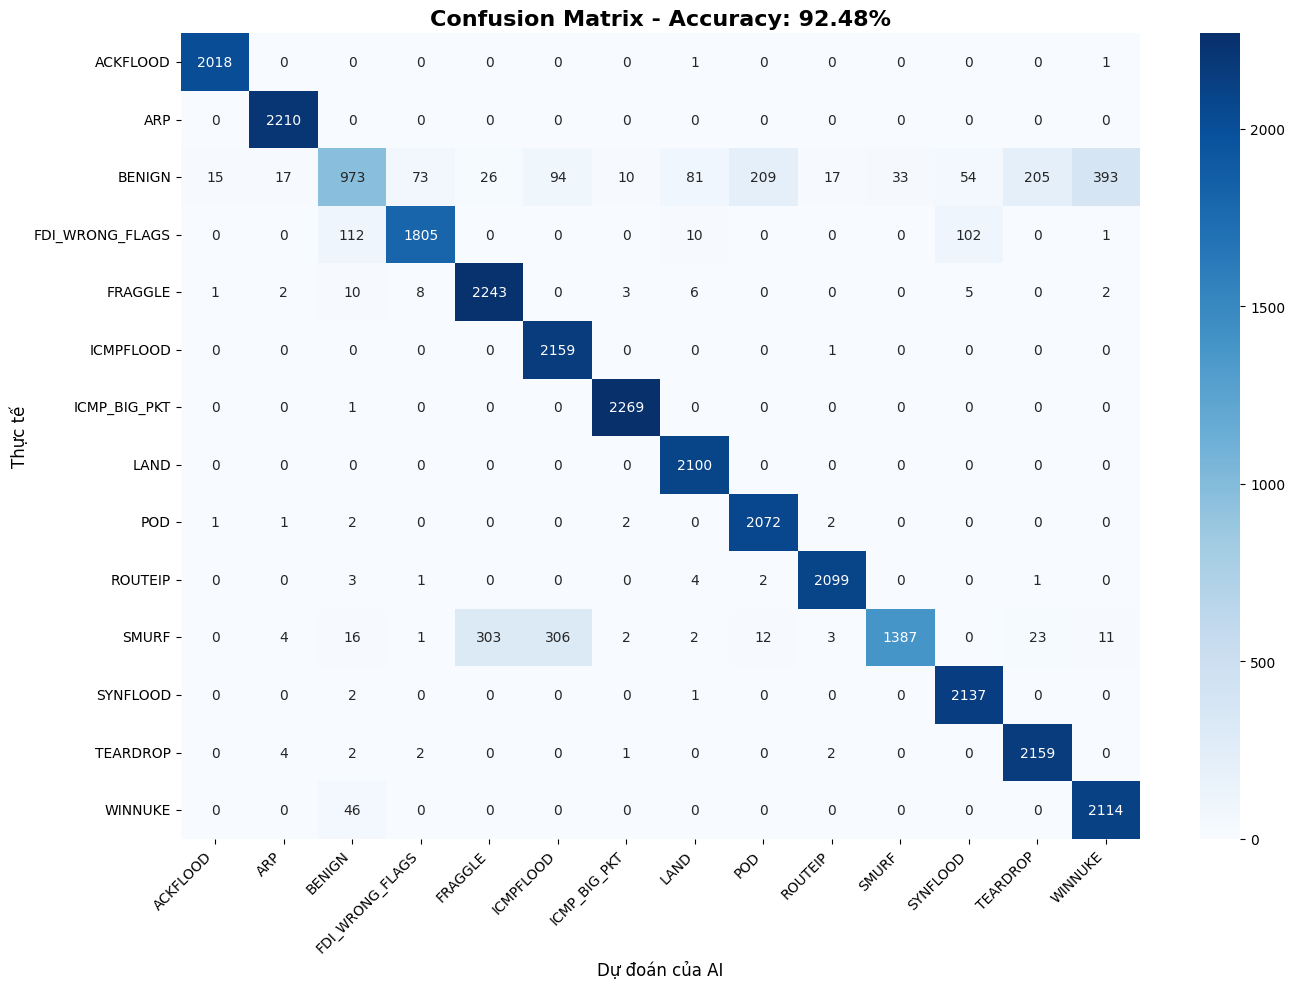

In [48]:
# Tải trọng số tốt nhất của nhánh Taxonomy trước khi đánh giá
met_model_tax.load_state_dict(torch.load("best_met_taxonomy.pth"))

# 1. Đo riêng độ phân loại đòn đã biết (Closed-set)
acc_tax_cs = evaluate_fast_closed_set(
    model=met_model_tax, 
    X_test_cs=X_test_tax_cs_gpu, 
    idx_test_cs=class_idx_test_tax_cs, 
    classes_test_cs=all_classes_test_tax_cs,
    le_label=le_label_tax,
    num_episodes=600,   # Có thể tăng lên 600-1000 để lấy số liệu chuẩn luận văn
    n_way=5, 
    k_shot=5, 
    n_query=10,
    device=device
)


 BẮT ĐẦU ĐÁNH GIÁ : CLOSED-SET ACCURACY


Testing Closed-set: 100%|██████████| 600/600 [00:11<00:00, 50.54it/s]



[+] ĐỘ CHÍNH XÁC PHÂN LOẠI (CLOSED-SET ACCURACY): 94.01%

 Chi tiết từng loại tấn công Schneider:
                 precision    recall  f1-score   support

       ACKFLOOD       0.91      1.00      0.95      2000
            ARP       0.99      1.00      0.99      2110
         BENIGN       0.81      0.95      0.87      2370
FDI_WRONG_FLAGS       0.97      0.82      0.89      2260
        FRAGGLE       0.87      0.99      0.93      2150
      ICMPFLOOD       0.88      1.00      0.94      2150
   ICMP_BIG_PKT       0.99      1.00      0.99      2190
           LAND       0.95      1.00      0.98      2340
            POD       1.00      0.99      1.00      2090
        ROUTEIP       0.99      1.00      0.99      2000
          SMURF       1.00      0.56      0.72      2130
       SYNFLOOD       0.92      1.00      0.96      2260
       TEARDROP       1.00      1.00      1.00      1910
        WINNUKE       0.99      0.86      0.92      2040

       accuracy                           0.

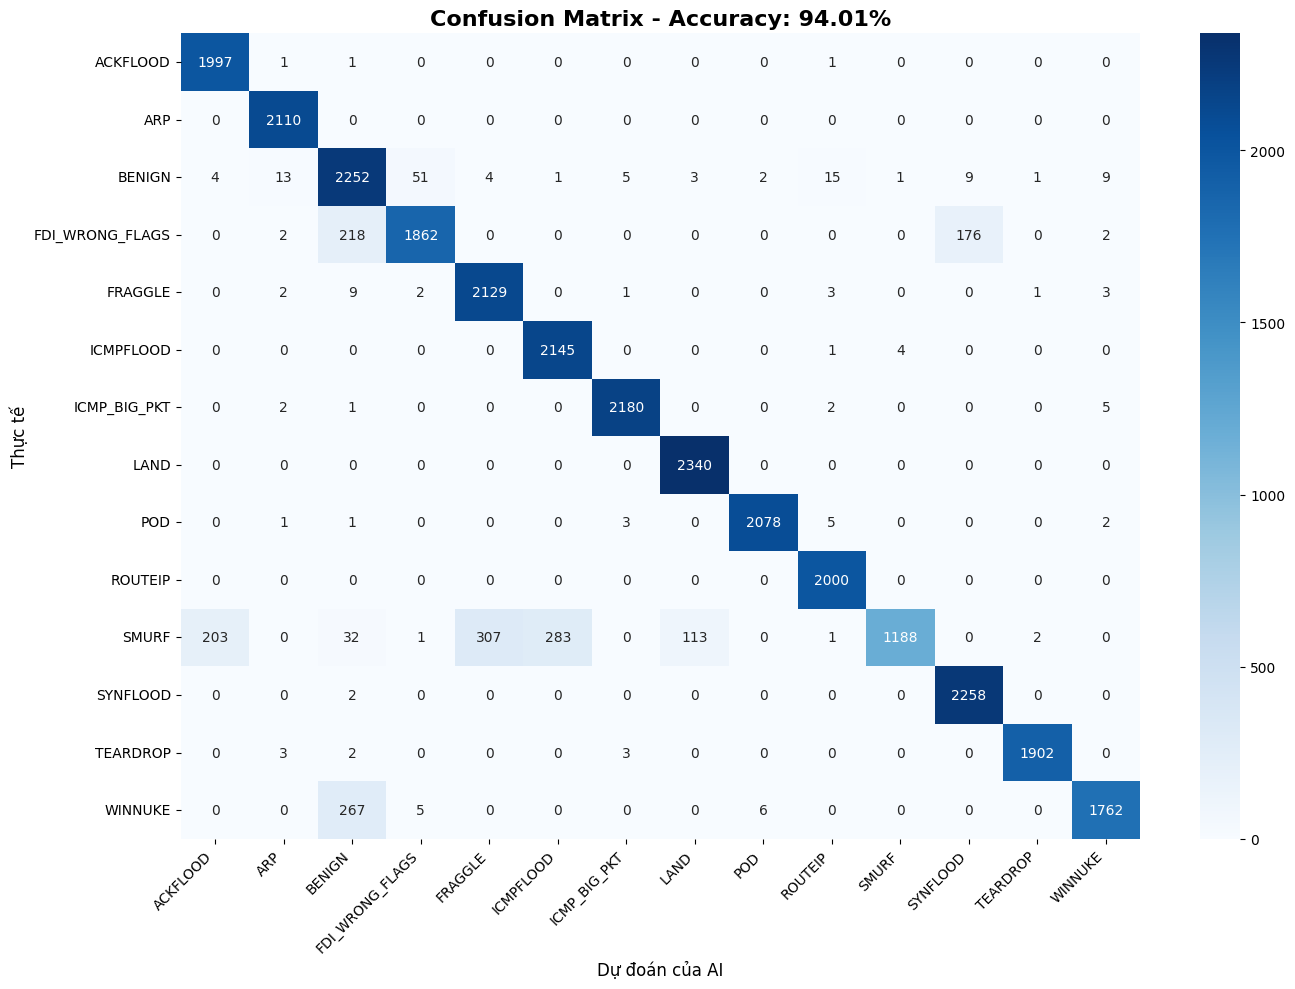

In [46]:
# Tải trọng số tốt nhất của nhánh Mahalanobis trước khi đánh giá
met_model_dist.load_state_dict(torch.load("best_met_mahalanobis.pth"))

# 1. Đo riêng độ phân loại đòn đã biết (Closed-set)
acc_dist_cs = evaluate_fast_closed_set(
    model=met_model_dist, 
    X_test_cs=X_test_dist_cs_gpu, 
    idx_test_cs=class_idx_test_dist_cs, 
    classes_test_cs=all_classes_test_dist_cs,
    le_label=le_label_dist,
    num_episodes=600,
    n_way=5, 
    k_shot=5, 
    n_query=10,
    device=device
)

# MODULE UNLEARNING

**Giai đoạn 1 - Trích xuất Dữ liệu Sửa lỗi**
* **Tập cần quên - FORGET (Df)**: Chứa TẤT CẢ các mẫu bị mô hình dự đoán sai (Bao gồm cảnh báo giả - FP, bỏ lọt - FN, nhận diện nhầm).
* **Tập giữ lại - RETAIN (Dr)**: Bốc ngẫu nhiên một tỷ lệ nhỏ (khoảng 30%) các mẫu mô hình đang dự đoán đúng để làm "mỏ neo" giữ gìn trí nhớ, chống hiện tượng quên thảm khốc (Catastrophic Unlearning).

In [71]:
import torch
import torch.nn.functional as F
import numpy as np
import copy
from torch.utils.data import TensorDataset, DataLoader

def extract_repair_sets(trained_met_model, X_tensor, Y_tensor,n_way=5, k_shot=5, n_query=10, num_eval_episodes=50, retain_ratio=0.3):
    """
    Chạy suy luận để nhặt ra TẤT CẢ các mẫu đoán sai (D_f) và mẫu đoán đúng (D_r).
    """
    print("\n[+] Đang chạy suy luận để tìm các mẫu cần sửa chữa (Misclassifications)...")
    trained_met_model.eval()

    all_classes = torch.unique(Y_tensor).tolist()

    wrong_X, wrong_Y = [], []
    correct_X, correct_Y = [], []
    
    with torch.no_grad():
        for ep in range(num_eval_episodes):
            # 1. Bốc ngẫu nhiên n_way lớp
            if len(all_classes) < n_way:
                sampled_classes = all_classes
            else:
                sampled_classes = random.sample(all_classes, n_way)
            
            support_X, query_X = [], []
            query_Y_global = [] # Nhãn thực tế (để lưu vào D_f, D_r)
            query_Y_local = []  # Nhãn cục bộ (0 đến 4) để chấm điểm mô hình
            
            # 2. Xây dựng Support Set và Query Set
            for local_label, cls in enumerate(sampled_classes):
                cls_indices = torch.nonzero(Y_tensor == cls).squeeze()
                if cls_indices.dim() == 0: cls_indices = cls_indices.unsqueeze(0)
                
                # Trộn ngẫu nhiên
                perm = torch.randperm(len(cls_indices))
                cls_indices = cls_indices[perm]
                
                # Bốc k_shot mẫu cho Support
                supp_idx = cls_indices[:k_shot]
                support_X.append(X_tensor[supp_idx])
                
                # Bốc n_query mẫu cho Query
                query_idx = cls_indices[k_shot : k_shot + n_query]
                query_X.append(X_tensor[query_idx])
                
                query_Y_global.append(Y_tensor[query_idx])
                query_Y_local.append(torch.full((len(query_idx),), local_label, dtype=torch.long))
                
            # Gộp lại thành 1 Episode
            SX = torch.cat(support_X, dim=0)
            QX = torch.cat(query_X, dim=0)
            episode_X = torch.cat([SX, QX], dim=0)
            
            QY_global = torch.cat(query_Y_global, dim=0)
            QY_local = torch.cat(query_Y_local, dim=0).to(X_tensor.device)
            
            # Đầu ra của MET_FewShot_Network là một Tuple
            outputs = trained_met_model(episode_X)
        
            if isinstance(outputs, tuple):
                evidence = outputs[0]
            else:
                evidence = outputs
            
            # Evidence trả về chỉ dành cho Query Set. Kích thước: [n_way * n_query, n_way]
            preds_local = torch.argmax(evidence, dim=1)
            
            # 4. Tìm lỗi dựa trên Nhãn cục bộ (Local Labels)
            wrong_mask = (preds_local != QY_local)
            correct_mask = (preds_local == QY_local)
            
            # Lưu lại mẫu lỗi (nhưng dùng Nhãn toàn cục để Unlearn)
            wrong_X.append(QX[wrong_mask])
            wrong_Y.append(QY_global[wrong_mask])
            
            correct_X.append(QX[correct_mask])
            correct_Y.append(QY_global[correct_mask])
        
   # ========================================================
    # GỘP TẤT CẢ LẠI THÀNH TẬP D_F VÀ D_R
    # ========================================================
    X_forget = torch.cat(wrong_X, dim=0)
    Y_forget = torch.cat(wrong_Y, dim=0)
    
    X_retain_pool = torch.cat(correct_X, dim=0)
    Y_retain_pool = torch.cat(correct_Y, dim=0)
    
    # Bốc một tỷ lệ nhỏ mẫu đúng làm neo giữ trí nhớ (D_r)
    num_retain = int(len(X_retain_pool) * retain_ratio)
    if num_retain > 0 and len(X_retain_pool) > 0:
        perm = torch.randperm(len(X_retain_pool))[:num_retain]
        X_retain = X_retain_pool[perm]
        Y_retain = Y_retain_pool[perm]
    else:
        X_retain = X_retain_pool
        Y_retain = Y_retain_pool
        
    print(f"-> Thu thập được {len(X_forget)} mẫu Dự đoán sai cần Tẩy não (Tập D_f).")
    print(f"-> Thu thập được {len(X_retain)} mẫu Dự đoán đúng làm Trí nhớ (Tập D_r).")
    
    return (X_forget, Y_forget), (X_retain, Y_retain)

**Giai đoạn 2 - Lõi Unlearning & Các Chỉ số Đánh giá**
* **Hàm Unlearning Step**: Sử dụng L_open của MET ép evidence của tập D_f về 0 (tạo độ bất định tối đa). Dùng KL-Divergence ép mô hình học sinh khớp với giáo viên trên tập D_r.
* **Chỉ số ZRF (Zero Retrain Forgetting)**: Đo mức độ dự đoán của mô hình trên tập D_f tiệm cận về phân phối ngẫu nhiên hoàn toàn. ZRF càng gần 1 càng tốt.
* Chỉ số MIA (Membership Inference Attack): Huấn luyện một mô hình SVM để "đoán" xem dữ liệu có nằm trong tập huấn luyện hay không dựa trên Shannon Entropy. Tỷ lệ MIA thấp chứng tỏ dữ liệu lỗi đã bị xóa sạch khỏi trí nhớ mạng Neural.

In [78]:
from torch.nn import functional as F
import torch
import numpy as np
from sklearn.svm import SVC

# ==========================================================
# CÁC HÀM TÍNH XÁC SUẤT VÀ LOSS CHO MET
# ==========================================================
def get_met_probabilities(evidence):
    """
    Thay thế cho F.softmax. Tính xác suất từ Evidence theo phân phối Dirichlet.
    """
    alpha = evidence + 1
    S = torch.sum(alpha, dim=1, keepdim=True)
    prob = alpha / S
    return prob

def unified_met_unlearning_step(student_model, competent_teacher, optimizer,X_support, X_query_retain, X_query_forget):
    """
    Bước Unlearning dành riêng cho mạng MET để sửa lỗi.
    """
    student_model.train()
    competent_teacher.eval() # Teacher luôn bị đóng băng
    
    optimizer.zero_grad()
    
    device = next(student_model.parameters()).device
    
    loss_forget = torch.tensor(0.0, device=device)
    loss_retain = torch.tensor(0.0, device=device)

    # 1. ÉP QUÊN CÁC MẪU LỖI DỰA TRÊN L_OPEN CỦA MET
    if len(X_query_forget) > 0:
        # Nối Support Set (từ D_r) và Query Set cần quên (từ D_f)
        episode_forget = torch.cat([X_support, X_query_forget], dim=0)
        
        # Đưa qua Student Model
        outputs_f = student_model(episode_forget)
        evidence_forget_all = outputs_f[0] if isinstance(outputs_f, tuple) else outputs_f
        
        # Chỉ lấy Evidence của phần Query (Bỏ qua phần Support ở đầu)
        query_evidence_f = evidence_forget_all[len(X_support):]
        
        # Ép evidence của D_f về 0 (Tối đa hóa độ bất định Vacuity)
        num_classes = query_evidence_f.shape[1]
        alpha_f = query_evidence_f + 1
        S_f = torch.sum(alpha_f, dim=1, keepdim=True)
        loss_forget = torch.mean(num_classes / S_f)

    # ========================================================
    
    # 2. GIỮ LẠI TRÍ NHỚ (RETAIN) BẰNG KL-DIVERGENCE
    if len(X_query_retain) > 0:
        episode_retain = torch.cat([X_support, X_query_retain], dim=0)
        
        # Student dự đoán
        outputs_s = student_model(episode_retain)
        evidence_retain_s_all = outputs_s[0] if isinstance(outputs_s, tuple) else outputs_s
        query_evidence_s = evidence_retain_s_all[len(X_support):]
        
        # Teacher Giỏi dự đoán
        with torch.no_grad():
            outputs_t = competent_teacher(episode_retain)
            evidence_retain_t_all = outputs_t[0] if isinstance(outputs_t, tuple) else outputs_t
            query_evidence_t = evidence_retain_t_all[len(X_support):]
            
        # Biến Evidence thành Xác suất (Dirichlet Mean)
        prob_s = get_met_probabilities(query_evidence_s)
        prob_t = get_met_probabilities(query_evidence_t)
        
        # Ép Student bắt chước y hệt Teacher bằng KL-Divergence
        loss_retain = F.kl_div(torch.log(prob_s + 1e-8), prob_t, reduction='batchmean')

    # ========================================================
    
    # 3. CẬP NHẬT TRỌNG SỐ (S)
    total_loss = loss_retain + 1.0 * loss_forget
    
    if total_loss.requires_grad:
        total_loss.backward()
        # Kẹp Gradient bảo vệ Transformer
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        optimizer.step()
    
    return loss_forget.item(), loss_retain.item()

In [84]:
# ==========================================================
# CÁC HÀM ĐÁNH GIÁ (METRICS)
# ==========================================================
def JSDiv(p, q):
    m = (p+q)/2
    return 0.5*F.kl_div(torch.log(p + 1e-8), m, reduction='batchmean') + \
           0.5*F.kl_div(torch.log(q + 1e-8), m, reduction='batchmean')

# 1. ZRF / UnLearningScore
def UnLearningScore_ZRF(unlearned_model, forget_tensor, device, num_classes=12):
    unlearned_model.eval()
    with torch.no_grad():
        outputs = unlearned_model(forget_tensor.to(device))
        evidence = outputs[0] if isinstance(outputs, (tuple, list)) else outputs
        prob_u = get_met_probabilities(evidence).cpu()
        
        # Phân phối của "Incompetent Teacher" (Ngẫu nhiên tuyệt đối)
        prob_dumb = torch.ones_like(prob_u) / num_classes
        
    js_div = JSDiv(prob_u, prob_dumb).item()
    return max(0.0, min(1.0, 1.0 - js_div))

# 2. MEMBERSHIP INFERENCE ATTACK (MIA)
def entropy(p, dim=-1, keepdim=False):
    # Tính Shannon Entropy
    return -torch.where(p > 0, p * p.log(), p.new([0.0])).sum(dim=dim, keepdim=keepdim)

def get_membership_attack_prob(retain_tensor, forget_tensor, test_tensor, model, device='cuda'):
    model.eval()
    
    def get_probs_safe(data):
        with torch.no_grad():
            outputs = model(data.to(device))
            evidence = outputs[0] if isinstance(outputs, (tuple, list)) else outputs
            return get_met_probabilities(evidence).cpu()
            
    prob_r = get_probs_safe(retain_tensor)
    prob_f = get_probs_safe(forget_tensor)
    prob_t = get_probs_safe(test_tensor)
        
    X_r = torch.cat([entropy(prob_r), entropy(prob_t)]).numpy().reshape(-1, 1)
    Y_r = np.concatenate([np.ones(len(prob_r)), np.zeros(len(prob_t))])
    
    X_f = entropy(prob_f).numpy().reshape(-1, 1)
    
    clf = SVC(C=3, gamma='auto', kernel='rbf')
    clf.fit(X_r, Y_r)
    results = clf.predict(X_f)
    
    # Trả về Tỷ lệ phần trăm kẻ địch tấn công / đoán trúng
    return results.mean() * 100 

# 3. ACTIVATION DISTANCE
@torch.no_grad()
def actv_dist(model1, model2, dataloader, device='cuda'):
    """
    Tính khoảng cách L2 (Euclidean) giữa phân phối xác suất của 2 mô hình.
    """
    model_orig.eval()
    model_unlearn.eval()
    
    distances = []
    for batch in dataloader:
        x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
        
        out_orig = model_orig(x)
        out_unl = model_unlearn(x)

        ev_orig = out_orig[0] if isinstance(out_orig, (tuple, list)) else out_orig
        ev_unl = out_unl[0] if isinstance(out_unl, (tuple, list)) else out_unl
        
        prob1 = get_met_probabilities(ev_orig)
        prob2 = get_met_probabilities(ev_unl)
        
        diff = torch.sqrt(torch.sum(torch.square(prob1 - prob2), dim=1))
        distances.append(diff.cpu())
        
    return torch.cat(distances).mean().item()

# Giai đoạn 3 - Vòng lặp Sửa chữa Tự động


In [86]:
import copy
import random

def auto_repair_met_integrated(original_model, D_f_tensor, D_r_tensor, 
                               sampling_method='mahalanobis', # Hoặc 'taxonomy'
                               mahalanobis_dist_matrix=None, taxonomy_dict=None,
                               class_to_indices_Dr=None, all_classes_Dr=None, # Index map của tập Retain
                               n_way=5, k_shot=5, n_query=10, 
                               unlearn_epochs=3, lr=1e-4, batch_size_forget=32):
    
    print(f"\n{'='*70}")
    print(f" MODULE MACHINE UNLEARNING ({sampling_method.upper()})")
    print(f"{'='*70}")
    
    # 1. Khởi tạo Học Sinh (S) và Giáo Viên Giỏi (Ts)
    competent_teacher = copy.deepcopy(original_model)
    competent_teacher.eval()
    for param in competent_teacher.parameters():
        param.requires_grad = False
        
    student_model = copy.deepcopy(original_model)
    student_model.train()
    optimizer = torch.optim.Adam(student_model.parameters(), lr=lr)
    
    # Số lượng mẫu Support trong 1 Episode
    support_size = n_way * k_shot
    
    # 2. Vòng lặp Sửa lỗi (Unlearning Loop)
    for epoch in range(1, unlearn_epochs + 1):
        total_l_f, total_l_r = 0, 0
        
        # Chạy khoảng 50 episodes mỗi epoch để sửa lỗi
        for step in range(50):
            # ---------------------------------------------------------
            # A. TẠO EPISODE GIỮ TRÍ NHỚ (Từ tập D_r)
            # ---------------------------------------------------------
            if sampling_method == 'mahalanobis':
                # Gọi hàm Mahalanobis đã viết của bạn
                X_episode_r, _, _, _ = get_episode_mahalanobis_fast(
                    X_tensor=D_r_tensor, class_to_indices=class_to_indices_Dr, 
                    all_classes=all_classes_Dr, dist_matrix=mahalanobis_dist_matrix, 
                    n_way=n_way, k_shot=k_shot, n_query=n_query, top_k_opponents=3, temperature=1.0
                )
            else:
                # Gọi hàm Taxonomy đã viết của bạn
                X_episode_r, _, _, _ = get_episode_taxonomy_fast(
                    X_tensor=D_r_tensor, class_to_indices=class_to_indices_Dr, 
                    all_classes=all_classes_Dr, taxonomy_dict=taxonomy_dict,
                    n_way=n_way, k_shot=k_shot, n_query=n_query
                )
                
            # Tách Support và Query từ Episode vừa bốc
            X_support = X_episode_r[:support_size]
            X_query_retain = X_episode_r[support_size:]
            
            # ---------------------------------------------------------
            # B. BỐC MẪU LỖI CẦN QUÊN (Từ tập D_f)
            # ---------------------------------------------------------
            if len(D_f_tensor) > 0:
                # Bốc ngẫu nhiên một batch các mẫu sai (FP, FN, v.v.)
                perm = torch.randperm(len(D_f_tensor), device=D_f_tensor.device)
                forget_idx = perm[:batch_size_forget]
                X_query_forget = D_f_tensor[forget_idx]
            else:
                X_query_forget = torch.empty(0, device=D_f_tensor.device)
            
            # ---------------------------------------------------------
            # C. CHẠY HÀM UNLEARNING
            # ---------------------------------------------------------
            l_f, l_r = unified_met_unlearning_step(
                student_model, competent_teacher, optimizer, 
                X_support, X_query_retain, X_query_forget
            )
            total_l_f += l_f
            total_l_r += l_r
            
        print(f"Epoch {epoch}/{unlearn_epochs} | Loss Xóa lỗi: {total_l_f/50:.4f} | Loss Giữ trí nhớ: {total_l_r/50:.4f}")

    print("\n[+] ĐÃ SỬA LỖI MÔ HÌNH THÀNH CÔNG BẰNG", sampling_method.upper(), "!")
    return student_model

# Giai đoạn 4 - Kịch bản Thực thi và Lấy Báo Cáo

In [103]:
# KỊCH BẢN VỚI CÂY PHÂN CẤP TAXONOMY

backbone_tax = FeatureExtractor_FT(
    num_features=len(feature_cols_tax), 
    embedding_dim=256,
    num_layers=2,
    nhead=8,
    dropout=0.1
).to(device)

best_met_tax_model = MET_FewShot_Network(
    backbone=backbone_tax,
    shot=5,      
    query=10, 
    hdim=256
).to(device)

best_met_tax_model.load_state_dict(torch.load("best_met_taxonomy.pth"))
best_met_tax_model.to(device)

# ====================================================================
# 1. Trích xuất dữ liệu lỗi từ tập Test/Eval 
# ====================================================================
X_eval_tax_raw = df_eval_tax_clean[top_features_tax].values
Y_eval_tax_raw = df_eval_tax_clean['Label'].values

X_eval_tax_tensor = torch.FloatTensor(X_eval_tax_raw).to(device)
Y_eval_tax_tensor = torch.LongTensor(Y_eval_tax_raw).to(device)

(X_forget, Y_forget), (X_retain, Y_retain) = extract_repair_sets(
    trained_met_model = best_met_tax_model, 
    X_tensor = X_eval_tax_tensor, 
    Y_tensor = Y_eval_tax_tensor, 
    n_way = 5,       # Trùng với cấu hình model của bạn
    k_shot = 5,      # Trùng với shot=5
    n_query = 10,    # Số mẫu query muốn test mỗi đợt
    num_eval_episodes = 50, # Chạy 20 đợt để thu thập đủ lỗi
    retain_ratio = 0.5
)

# ====================================================================
# 2. Chuẩn bị Metadata (Index Map) riêng cho tập D_r để Sampler hoạt động
# ====================================================================
print("\n[+] Đang chuẩn bị Metadata cho tập Retain (D_r)...")
all_classes_Dr = torch.unique(Y_retain).tolist()
class_to_indices_Dr = {}

for cls in all_classes_Dr:
    indices = torch.nonzero(Y_retain == cls).squeeze()
    if indices.dim() == 0:
        indices = indices.unsqueeze(0)
    class_to_indices_Dr[cls] = indices

# ====================================================================
# 3. CHÍNH THỨC SỬA LỖI MÔ HÌNH
# ====================================================================
if len(X_forget) > 0:
    repaired_met_tax_model = auto_repair_met_integrated(
        original_model=best_met_tax_model,
        D_f_tensor=X_forget,
        D_r_tensor=X_retain,
        sampling_method='taxonomy', # Thử đổi thành 'taxonomy' để xem kết quả
        taxonomy_dict=ics_taxonomy, 
        class_to_indices_Dr=class_to_indices_Dr, 
        all_classes_Dr=all_classes_Dr,
        n_way=5, k_shot=5, n_query=10,
        unlearn_epochs=5, lr=5e-5
    )
    # LƯU LẠI MÔ HÌNH ĐÃ SỬA LỖI
    torch.save(repaired_met_tax_model.state_dict(), "repaired_met_taxonomy.pth")
    print("[+] Đã lưu mô hình Unlearned thành công!")
else:
    print("[!] Không có mẫu lỗi nào cần Unlearn. Mô hình đã hoàn hảo!")
    repaired_met_tax_model = best_met_tax_model

# ====================================================================
# 4. BÁO CÁO NGHIỆM THU (EVALUATION METRICS)
# ====================================================================
print(f"\n{'='*60}")
print(f" BÁO CÁO CHỨNG NHẬN MACHINE UNLEARNING")
print(f"{'='*60}")

# Giả sử X_test_new là tập test chưa từng nhìn thấy để làm mồi cho hàm MIA
# Nếu không có, bạn có thể lấy 1 phần X_eval làm X_test_new
X_test_new = X_eval_tax_tensor[-1000:] 

# Tính ZRF
zrf_score = UnLearningScore_ZRF(repaired_met_tax_model, X_forget, device)
print(f"[*] Điểm ZRF (Zero Retrain Forgetting): {zrf_score:.4f} (Kỳ vọng tiến gần về 1.0)")

# Tính Khả năng bị tấn công (MIA)
mia_original = get_membership_attack_prob(X_retain, X_forget, X_test_new, best_met_tax_model, device)
mia_unlearned = get_membership_attack_prob(X_retain, X_forget, X_test_new, repaired_met_tax_model, device)

print(f"[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình GỐC:      {mia_original:.2f}%")
print(f"[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình UNLEARNED: {mia_unlearned:.2f}% (Kỳ vọng giảm mạnh)")
print(f"{'='*60}")


[+] Đang chạy suy luận để tìm các mẫu cần sửa chữa (Misclassifications)...
-> Thu thập được 1118 mẫu Dự đoán sai cần Tẩy não (Tập D_f).
-> Thu thập được 691 mẫu Dự đoán đúng làm Trí nhớ (Tập D_r).

[+] Đang chuẩn bị Metadata cho tập Retain (D_r)...

 MODULE MACHINE UNLEARNING (TAXONOMY)
Epoch 1/5 | Loss Xóa lỗi: 0.8294 | Loss Giữ trí nhớ: 0.0268
Epoch 2/5 | Loss Xóa lỗi: 0.8024 | Loss Giữ trí nhớ: 0.0277
Epoch 3/5 | Loss Xóa lỗi: 0.7937 | Loss Giữ trí nhớ: 0.0269
Epoch 4/5 | Loss Xóa lỗi: 0.7653 | Loss Giữ trí nhớ: 0.0280
Epoch 5/5 | Loss Xóa lỗi: 0.7547 | Loss Giữ trí nhớ: 0.0317

[+] ĐÃ SỬA LỖI MÔ HÌNH THÀNH CÔNG BẰNG TAXONOMY !
[+] Đã lưu mô hình Unlearned thành công!

 BÁO CÁO CHỨNG NHẬN MACHINE UNLEARNING
[*] Điểm ZRF (Zero Retrain Forgetting): 0.9151 (Kỳ vọng tiến gần về 1.0)
[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình GỐC:      0.00%
[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình UNLEARNED: 0.00% (Kỳ vọng giảm mạnh)


In [115]:
# KỊCH BẢN VỚI MA TRẬN KHOẢNG CÁCH MAHALANOBIS

# 1. Khởi tạo Model mới
backbone_dist = FeatureExtractor_FT(
    num_features=len(feature_cols_dist), 
    embedding_dim=256,
    num_layers=2,
    nhead=8,
    dropout=0.1
).to(device)

best_met_dist_model = MET_FewShot_Network(
    backbone=backbone_dist,
    shot=5,      
    query=10, 
    hdim=256
).to(device)

best_met_dist_model.load_state_dict(torch.load("best_met_mahalanobis.pth"))
best_met_dist_model.to(device)

# ====================================================================
# 1. Trích xuất dữ liệu lỗi từ tập Test/Eval (Giả sử X_eval, Y_eval đã có sẵn)
# ====================================================================
X_eval_dist_raw = df_eval_tax_clean[top_features_tax].values
Y_eval_dist_raw = df_eval_tax_clean['Label'].values

X_eval_dist_tensor = torch.FloatTensor(X_eval_dist_raw).to(device)
Y_eval_dist_tensor = torch.LongTensor(Y_eval_dist_raw).to(device)

(X_forget, Y_forget), (X_retain, Y_retain) = extract_repair_sets(
    trained_met_model = best_met_dist_model, 
    X_tensor = X_eval_dist_tensor, 
    Y_tensor = Y_eval_dist_tensor, 
    n_way = 5,       # Trùng với cấu hình model của bạn
    k_shot = 5,      # Trùng với shot=5
    n_query = 10,    # Số mẫu query muốn test mỗi đợt
    num_eval_episodes = 50, # Chạy 20 đợt để thu thập đủ lỗi
    retain_ratio = 0.5
)
# ====================================================================
# 2. Chuẩn bị Metadata (Index Map) riêng cho tập D_r để Sampler hoạt động
# ====================================================================
print("\n[+] Đang chuẩn bị Metadata cho tập Retain (D_r)...")
all_classes_Dr = torch.unique(Y_retain).tolist()
class_to_indices_Dr = {}

for cls in all_classes_Dr:
    indices = torch.nonzero(Y_retain == cls).squeeze()
    if indices.dim() == 0:
        indices = indices.unsqueeze(0)
    class_to_indices_Dr[cls] = indices

# ====================================================================
# 3. CHÍNH THỨC SỬA LỖI MÔ HÌNH
# ====================================================================
if len(X_forget) > 0:
    repaired_met_dist_model = auto_repair_met_integrated(
        original_model=best_met_dist_model,
        D_f_tensor=X_forget,
        D_r_tensor=X_retain,
        sampling_method='mahalanobis', # Thử đổi thành 'taxonomy' để xem kết quả
        mahalanobis_dist_matrix=final_train_dist_matrix, 
        class_to_indices_Dr=class_to_indices_Dr, 
        all_classes_Dr=all_classes_Dr,
        n_way=5, k_shot=5, n_query=10,
        unlearn_epochs=5, lr=5e-5
    )
    
    # LƯU LẠI MÔ HÌNH ĐÃ SỬA LỖI
    torch.save(repaired_met_dist_model.state_dict(), "repaired_met_mahalanobis.pth")
    print("[+] Đã lưu mô hình Unlearned thành công!")
else:
    print("[!] Không có mẫu lỗi nào cần Unlearn. Mô hình đã hoàn hảo!")
    repaired_met_dist_model = best_met_dist_model

# ====================================================================
# 4. BÁO CÁO NGHIỆM THU (EVALUATION METRICS)
# ====================================================================
print(f"\n{'='*60}")
print(f" BÁO CÁO CHỨNG NHẬN MACHINE UNLEARNING")
print(f"{'='*60}")

# Giả sử X_test_new là tập test chưa từng nhìn thấy để làm mồi cho hàm MIA
# Nếu không có, bạn có thể lấy 1 phần X_eval làm X_test_new
X_test_new = X_eval_dist_tensor[-1000:]

# Tính ZRF
zrf_score = UnLearningScore_ZRF(repaired_met_dist_model, X_forget, device)
print(f"[*] Điểm ZRF (Zero Retrain Forgetting): {zrf_score:.4f} (Kỳ vọng tiến gần về 1.0)")

# Tính Khả năng bị tấn công (MIA)
mia_original = get_membership_attack_prob(X_retain, X_forget, X_test_new, best_met_dist_model, device)
mia_unlearned = get_membership_attack_prob(X_retain, X_forget, X_test_new, repaired_met_dist_model, device)

print(f"[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình GỐC:      {mia_original:.2f}%")
print(f"[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình UNLEARNED: {mia_unlearned:.2f}% (Kỳ vọng giảm mạnh)")
print(f"{'='*60}")


[+] Đang chạy suy luận để tìm các mẫu cần sửa chữa (Misclassifications)...
-> Thu thập được 1396 mẫu Dự đoán sai cần Tẩy não (Tập D_f).
-> Thu thập được 552 mẫu Dự đoán đúng làm Trí nhớ (Tập D_r).

[+] Đang chuẩn bị Metadata cho tập Retain (D_r)...

 MODULE MACHINE UNLEARNING (MAHALANOBIS)
Epoch 1/5 | Loss Xóa lỗi: 0.6628 | Loss Giữ trí nhớ: 0.0753
Epoch 2/5 | Loss Xóa lỗi: 0.6140 | Loss Giữ trí nhớ: 0.0709
Epoch 3/5 | Loss Xóa lỗi: 0.5965 | Loss Giữ trí nhớ: 0.0758
Epoch 4/5 | Loss Xóa lỗi: 0.5949 | Loss Giữ trí nhớ: 0.0782
Epoch 5/5 | Loss Xóa lỗi: 0.6017 | Loss Giữ trí nhớ: 0.0840

[+] ĐÃ SỬA LỖI MÔ HÌNH THÀNH CÔNG BẰNG MAHALANOBIS !
[+] Đã lưu mô hình Unlearned thành công!

 BÁO CÁO CHỨNG NHẬN MACHINE UNLEARNING
[*] Điểm ZRF (Zero Retrain Forgetting): 0.9119 (Kỳ vọng tiến gần về 1.0)
[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình GỐC:      0.00%
[*] Tỷ lệ rò rỉ dữ liệu (MIA) Mô hình UNLEARNED: 0.00% (Kỳ vọng giảm mạnh)



 KIỂM ĐỊNH BẢO TOÀN HIỆU NĂNG (UTILITY PRESERVATION)

[4] ĐÁNH GIÁ CLOSED-SET: MÔ HÌNH TAXONOMY (UNLEARNED)

 BẮT ĐẦU ĐÁNH GIÁ : CLOSED-SET ACCURACY


Testing Closed-set: 100%|██████████| 600/600 [00:11<00:00, 51.48it/s]



[+] ĐỘ CHÍNH XÁC PHÂN LOẠI (CLOSED-SET ACCURACY): 92.57%

 Chi tiết từng loại tấn công Schneider:
                 precision    recall  f1-score   support

       ACKFLOOD       0.98      1.00      0.99      2330
            ARP       0.99      1.00      1.00      2160
         BENIGN       0.82      0.47      0.60      2130
FDI_WRONG_FLAGS       0.96      0.88      0.92      2170
        FRAGGLE       0.88      0.99      0.93      2120
      ICMPFLOOD       0.84      0.99      0.91      1990
   ICMP_BIG_PKT       0.99      1.00      0.99      2140
           LAND       0.96      1.00      0.98      2360
            POD       0.87      1.00      0.93      2020
        ROUTEIP       0.99      1.00      0.99      1940
          SMURF       0.96      0.69      0.80      2230
       SYNFLOOD       0.93      1.00      0.96      2220
       TEARDROP       0.92      1.00      0.96      2040
        WINNUKE       0.86      0.96      0.91      2150

       accuracy                           0.

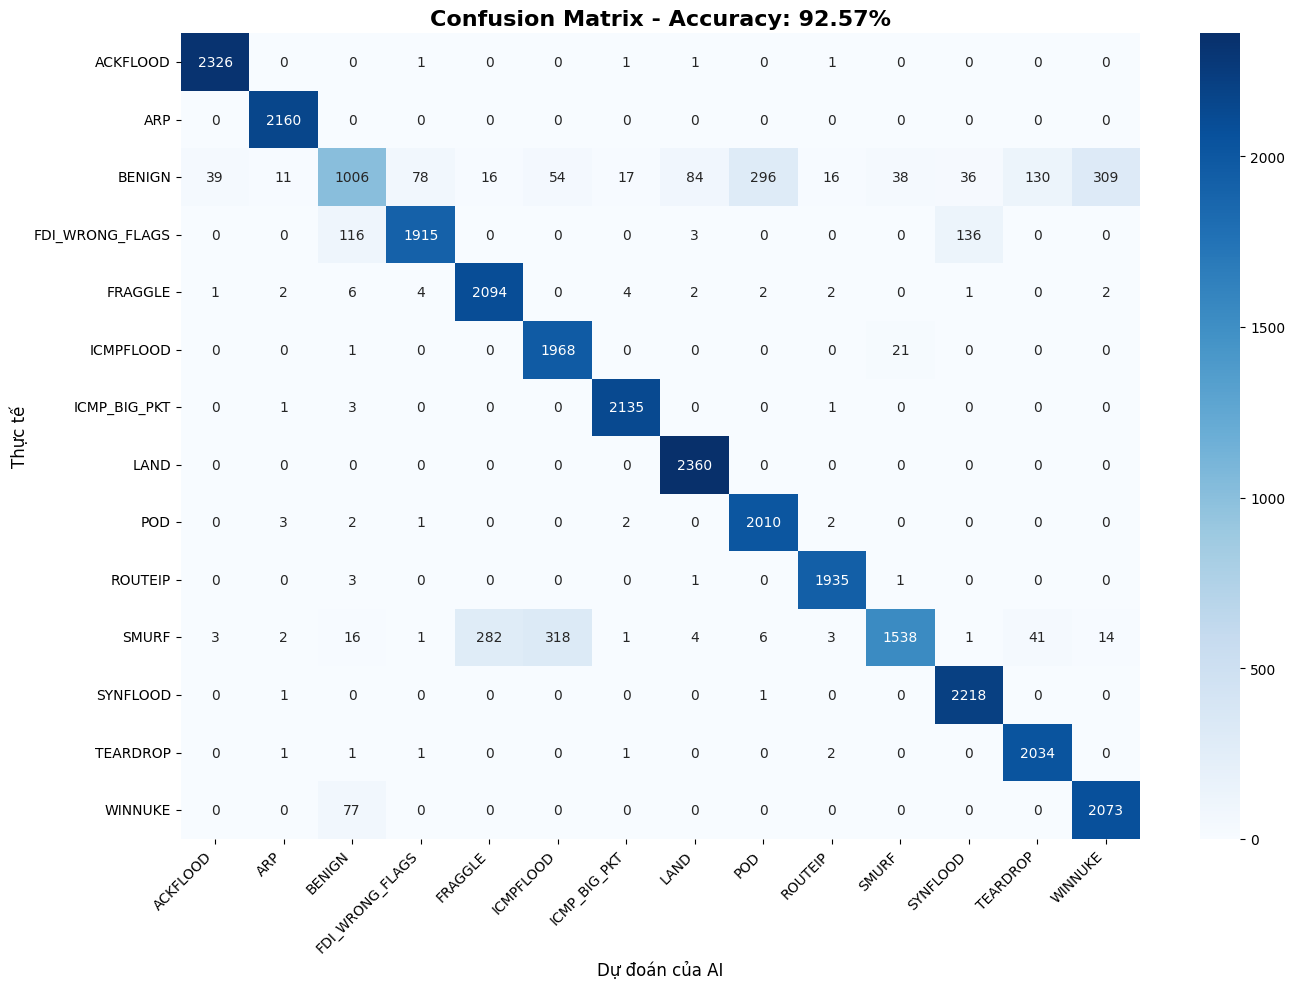

In [117]:
print(f"\n{'='*70}")
print(f" KIỂM ĐỊNH BẢO TOÀN HIỆU NĂNG (UTILITY PRESERVATION)")
print(f"{'='*70}")

# 1. Đánh giá mô hình Taxonomy sau khi sửa lỗi
print("\n[4] ĐÁNH GIÁ CLOSED-SET: MÔ HÌNH TAXONOMY (UNLEARNED)")
# Truyền biến repaired_met_tax_model của bạn vào hàm đánh giá cũ
# (Lưu ý: Thay tham số sao cho khớp với hàm evaluate_fast_closed_set mà bạn đã định nghĩa)
repaired_met_tax_model.load_state_dict(torch.load("repaired_met_taxonomy.pth"))

acc_tax_unlearned = evaluate_fast_closed_set(
    model=repaired_met_tax_model, 
    X_test_cs=X_test_tax_cs_gpu, 
    idx_test_cs=class_idx_test_tax_cs, 
    classes_test_cs=all_classes_test_tax_cs,
    le_label=le_label_tax,
    num_episodes=600,
    n_way=5, 
    k_shot=5, 
    n_query=10,
    device=device
)




[5] ĐÁNH GIÁ CLOSED-SET: MÔ HÌNH MAHALANOBIS (UNLEARNED)

 BẮT ĐẦU ĐÁNH GIÁ : CLOSED-SET ACCURACY


Testing Closed-set: 100%|██████████| 600/600 [00:11<00:00, 51.02it/s]



[+] ĐỘ CHÍNH XÁC PHÂN LOẠI (CLOSED-SET ACCURACY): 93.86%

 Chi tiết từng loại tấn công Schneider:
                 precision    recall  f1-score   support

       ACKFLOOD       0.92      1.00      0.96      2040
            ARP       0.99      1.00      1.00      2510
         BENIGN       0.80      0.95      0.87      2230
FDI_WRONG_FLAGS       0.93      0.85      0.88      2000
        FRAGGLE       0.84      0.99      0.91      2240
      ICMPFLOOD       0.89      1.00      0.94      2030
   ICMP_BIG_PKT       1.00      1.00      1.00      2000
           LAND       0.96      1.00      0.98      2160
            POD       1.00      1.00      1.00      2100
        ROUTEIP       0.99      1.00      0.99      2110
          SMURF       0.97      0.58      0.73      2090
       SYNFLOOD       0.95      1.00      0.97      2090
       TEARDROP       1.00      0.99      0.99      2320
        WINNUKE       0.98      0.79      0.87      2080

       accuracy                           0.

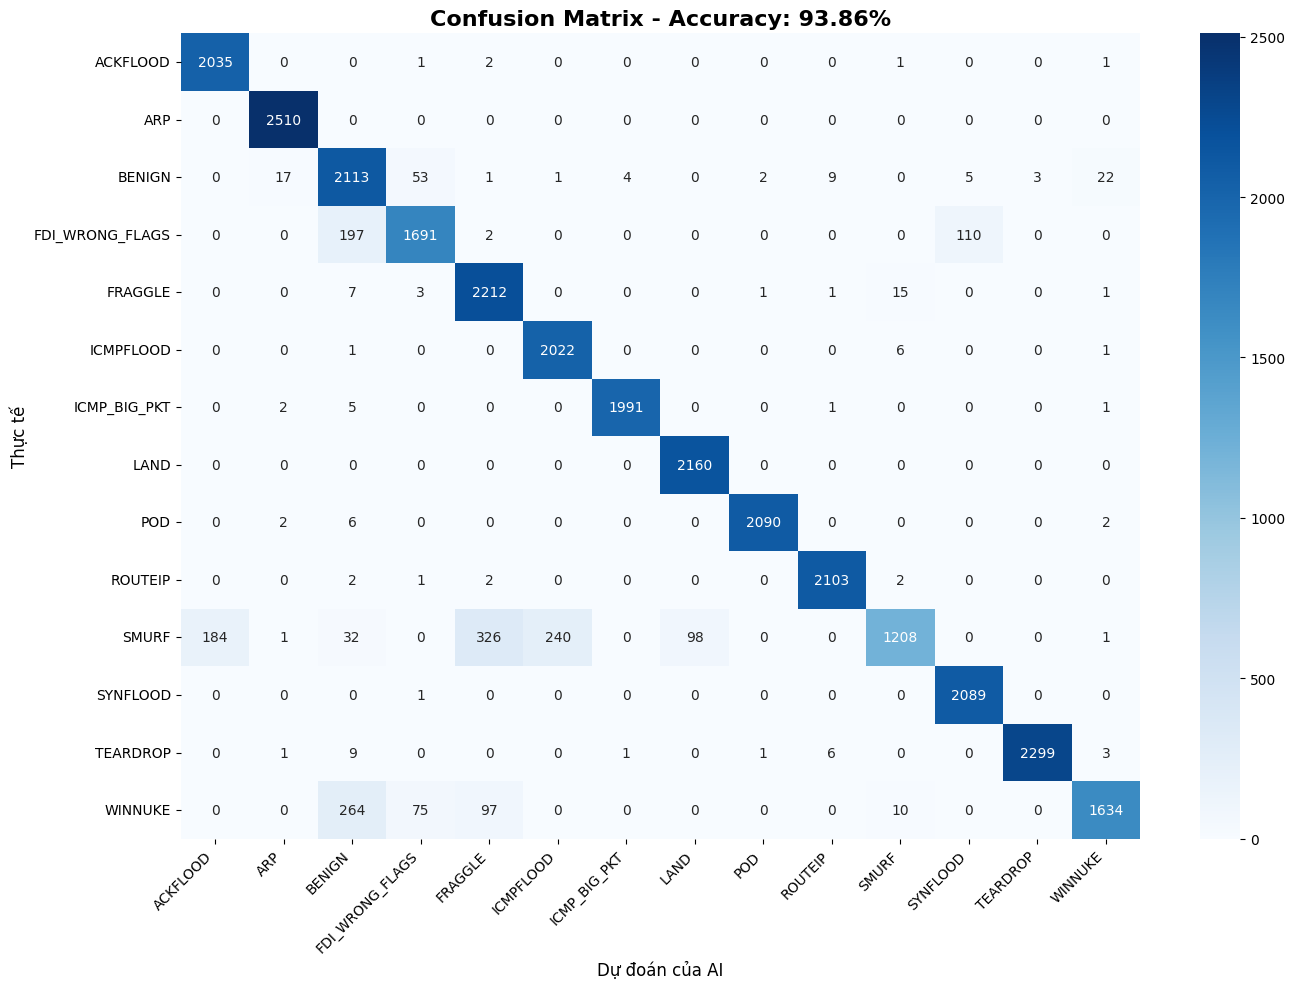

In [118]:
# 2. Đánh giá mô hình Mahalanobis sau khi sửa lỗi
print("\n[5] ĐÁNH GIÁ CLOSED-SET: MÔ HÌNH MAHALANOBIS (UNLEARNED)")
# Truyền biến repaired_met_mahalanobis (hoặc repaired_met_model của nhánh Mahalanobis)
repaired_met_dist_model.load_state_dict(torch.load("repaired_met_mahalanobis.pth"))

acc_mah_unlearned = evaluate_fast_closed_set(
    model=repaired_met_dist_model, 
    X_test_cs=X_test_dist_cs_gpu, 
    idx_test_cs=class_idx_test_dist_cs, 
    classes_test_cs=all_classes_test_dist_cs,
    le_label=le_label_dist,
    num_episodes=600,
    n_way=5, 
    k_shot=5, 
    n_query=10,
    device=device
)